# Phase 1: Deep Data Characterization — IC vs K-Wave

**Goal**: Understand *why* INR works on inverse-crime data but struggles on k-wave, by deeply exploring the data characteristics of both domains.

**Sections**:
1. Raw data inspection — shapes, ranges, NaN patterns
2. Ground truth visualization — what do the SoS maps look like?
3. Measurement domain — IC vs k-wave displacement distributions
4. Mask analysis — how much data is invalid?
5. Forward model mismatch — ε = d_meas - L@s_true
6. L1/L2 baseline comparison — what do classical methods recover?
7. Condition number and spectral analysis of L
8. Per-firing-pair mismatch structure

In [3]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.sparse import csc_matrix
from scipy import linalg
import warnings
import inr_sos
from inr_sos import DATA_DIR

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

# ── Paths ──────────────────────────────────────────────────────────────────
KWAVE_GEOM_PATH = DATA_DIR + "/DL-based-SoS/test_kWaveGeom_l2rec_l1rec_unifiedvar.mat"
KWAVE_BLOB_PATH = DATA_DIR + "/DL-based-SoS/test_kWaveBlob_final.mat"
GRID_PATH       = DATA_DIR + "/DL-based-SoS/forward_model_lr/grid_parameters.mat"
L_PATH          = DATA_DIR + "/DL-based-SoS/A.mat"
kwave_geom_unet = DATA_DIR + "/DL-based-SoS/NetworkMeasL2L1_geom_ipapdistprojnet.mat"
kwave_geom_diffusion = DATA_DIR + "/DL-based-SoS/NetworkMeasL2L1geom_C64_L12222_ipmapmadismapneout_l1_0f_w1ddpm.mat"
kwave_blob_unet = DATA_DIR + "/DL-based-SoS/NetworkMeasL2L1_blobtest_ipapdistprojnet.mat"
kwave_blob_diffusion = DATA_DIR + "/DL-based-SoS/NetworkMeasL2L1blobtest_C64_L12222_ipmapmadismapneout_l1_0f_w1ddpm.mat"

arranged_allmeas  = DATA_DIR + "/DL-based-SoS/arranged_allmeas_pred_train_networkoutts25.mat"

# IC data for comparison
IC_PATH         = DATA_DIR + "/DL-based-SoS/train-VS-8pairs-IC-081225.mat"

print(f"DATA_DIR: {DATA_DIR}")
print("Paths configured.")

DATA_DIR: /mnt/asgard0/data/haben/data
Paths configured.


## 1. Raw Data Inspection

First, let's understand the structure and shapes of all three datasets (IC, kwave_geom, kwave_blob) and the L-matrix.

In [4]:
def inspect_h5(path, label):
    """Print all keys, shapes, and basic stats for an HDF5 file."""
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  {path}")
    print(f"{'='*60}")
    with h5py.File(path, 'r') as f:
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                arr = obj[:]
                nan_count = np.isnan(arr).sum() if np.issubdtype(arr.dtype, np.floating) else 0
                print(f"  {name:40s} shape={str(obj.shape):20s} dtype={str(obj.dtype):10s} "
                      f"min={arr[~np.isnan(arr)].min() if nan_count < arr.size else 'all-NaN':>12} "
                      f"max={arr[~np.isnan(arr)].max() if nan_count < arr.size else 'all-NaN':>12} "
                      f"NaN={nan_count}")
            elif isinstance(obj, h5py.Group):
                print(f"  {name:40s} [GROUP] keys={list(obj.keys())}")
        f.visititems(visit)

#inspect_h5(IC_PATH, "Inverse Crime (IC)")
#inspect_h5(KWAVE_GEOM_PATH, "K-Wave Geom")
#inspect_h5(KWAVE_BLOB_PATH, "K-Wave Blob")

In [6]:
#inspect_h5(arranged_allmeas, "arranged_allmeas")
inspect_h5(kwave_geom_unet, "K-Wave Geom UNet")
inspect_h5(kwave_geom_diffusion, "K-Wave Geom Diffusion")
inspect_h5(kwave_blob_unet, "K-Wave Blob UNet")
inspect_h5(kwave_blob_diffusion, "K-Wave Blob Diffusion") 


  K-Wave Geom UNet
  /mnt/asgard0/data/haben/data/DL-based-SoS/NetworkMeasL2L1_geom_ipapdistprojnet.mat
  MaskSoS                                  shape=(8, 128, 128)        dtype=float64    min=         1.0 max=         1.0 NaN=56170
  all_correlation_vector                   shape=(32, 131072)         dtype=float64    min=0.20104809105396362 max=0.9670726060867311 NaN=3597324
  all_slowness_recons_l1                   shape=(32, 64, 64)         dtype=float64    min=0.0006518292588611052 max=0.0006883197236519324 NaN=0
  all_slowness_recons_l2                   shape=(32, 64, 64)         dtype=float64    min=0.0006529661898426608 max=0.0006790499810589941 NaN=0
  bf_sos                                   shape=(1, 1)               dtype=float64    min=      1510.0 max=      1510.0 NaN=0
  imgs_gt                                  shape=(32, 64, 64)         dtype=float64    min=0.0006451612903225799 max=0.0007142857142857145 NaN=0
  measmnts                                 shape=(32, 13

In [23]:
# Load the L-matrix — SAME matrix for all datasets (IC, kwave_geom, kwave_blob)
# Storage varies: dense in IC, sparse CSC in kwave_geom, absent in kwave_blob.
# Load from kwave_geom (sparse) and IC (dense), confirm they match, then use one.

def load_L_from_h5(path):
    """Load L-matrix handling dense Dataset or sparse CSC Group."""
    with h5py.File(path, 'r') as f:
        if 'A' not in f:
            return None
        node = f['A']
        if isinstance(node, h5py.Group):
            # Sparse CSC
            data = node['data'][:]
            ir = node['ir'][:]
            jc = node['jc'][:]
            n_cols = len(jc) - 1
            n_rows = int(ir.max()) + 1 if len(ir) > 0 else 0
            return csc_matrix((data, ir, jc), shape=(n_rows, n_cols)).toarray()
        else:
            # Dense — IC stores as (4096, 131072), need to transpose
            A = np.array(node)
            if A.shape[0] < A.shape[1]:
                A = A.T
            return A

print("Loading L from IC (dense)...")
L_ic = load_L_from_h5(IC_PATH)
print(f"  L_ic shape: {L_ic.shape}")

print("Loading L from kwave_geom (sparse CSC)...")
L_kw = load_L_from_h5(KWAVE_GEOM_PATH)
print(f"  L_kw shape: {L_kw.shape}")

print("Loading L from kwave_blob...")
L_blob = load_L_from_h5(KWAVE_BLOB_PATH)
print(f"  L_blob: {'NOT embedded (expected — supervisor ships it separately)' if L_blob is None else L_blob.shape}")

# Confirm they are identical
diff = np.abs(L_ic - L_kw).max()
print(f"\nMax |L_ic - L_kw|: {diff:.2e}")
print(f"✓ CONFIRMED: Same L-matrix across datasets (diff = {diff})")

# Use one copy going forward
L = L_kw
print(f"\nUsing L with shape {L.shape} for all analysis")
print(f"  Non-zero entries: {np.count_nonzero(L):,} / {L.size:,} ({np.count_nonzero(L)/L.size*100:.1f}%)")
print(f"  Value range: [{L.min():.6e}, {L.max():.6e}]")

Loading L from IC (dense)...
  L_ic shape: (131072, 4096)
Loading L from kwave_geom (sparse CSC)...
  L_kw shape: (131072, 4096)
Loading L from kwave_blob...
  L_blob: NOT embedded (expected — supervisor ships it separately)

Max |L_ic - L_kw|: 0.00e+00
✓ CONFIRMED: Same L-matrix across datasets (diff = 0.0)

Using L with shape (131072, 4096) for all analysis
  Non-zero entries: 74,580,122 / 536,870,912 (13.9%)
  Value range: [-5.524384e-04, 5.424195e-04]


## 2. Ground Truth Visualization

Compare what the SoS maps look like across domains. IC uses analytical phantoms; k-wave uses full-wave simulated phantoms with different inclusion geometries.

In [24]:
def load_samples(path, indices, keys=('imgs_gt', 'measmnts', 'nanidx')):
    """Load specific samples from an HDF5 file."""
    data = {}
    with h5py.File(path, 'r') as f:
        for key in keys:
            if key in f:
                data[key] = np.array([f[key][i] for i in indices])
            else:
                print(f"  Warning: '{key}' not found in {path}")
        # Also grab optional fields
        for opt_key in ('all_slowness_recons_l1', 'all_slowness_recons_l2', 'all_correlation_vector'):
            if opt_key in f:
                data[opt_key] = np.array([f[opt_key][i] for i in indices])
    return data

# Load a few samples from each dataset
sample_indices = [0, 1, 2, 3, 4, 5]

ic_data = load_samples(IC_PATH, sample_indices)
kw_geom_data = load_samples(KWAVE_GEOM_PATH, sample_indices)
kw_blob_data = load_samples(KWAVE_BLOB_PATH, sample_indices)

print(f"IC:        imgs_gt shape = {ic_data['imgs_gt'].shape}")
print(f"KW Geom:   imgs_gt shape = {kw_geom_data['imgs_gt'].shape}")
print(f"KW Blob:   imgs_gt shape = {kw_blob_data['imgs_gt'].shape}")

IC:        imgs_gt shape = (6, 64, 64)
KW Geom:   imgs_gt shape = (6, 64, 64)
KW Blob:   imgs_gt shape = (6, 64, 64)


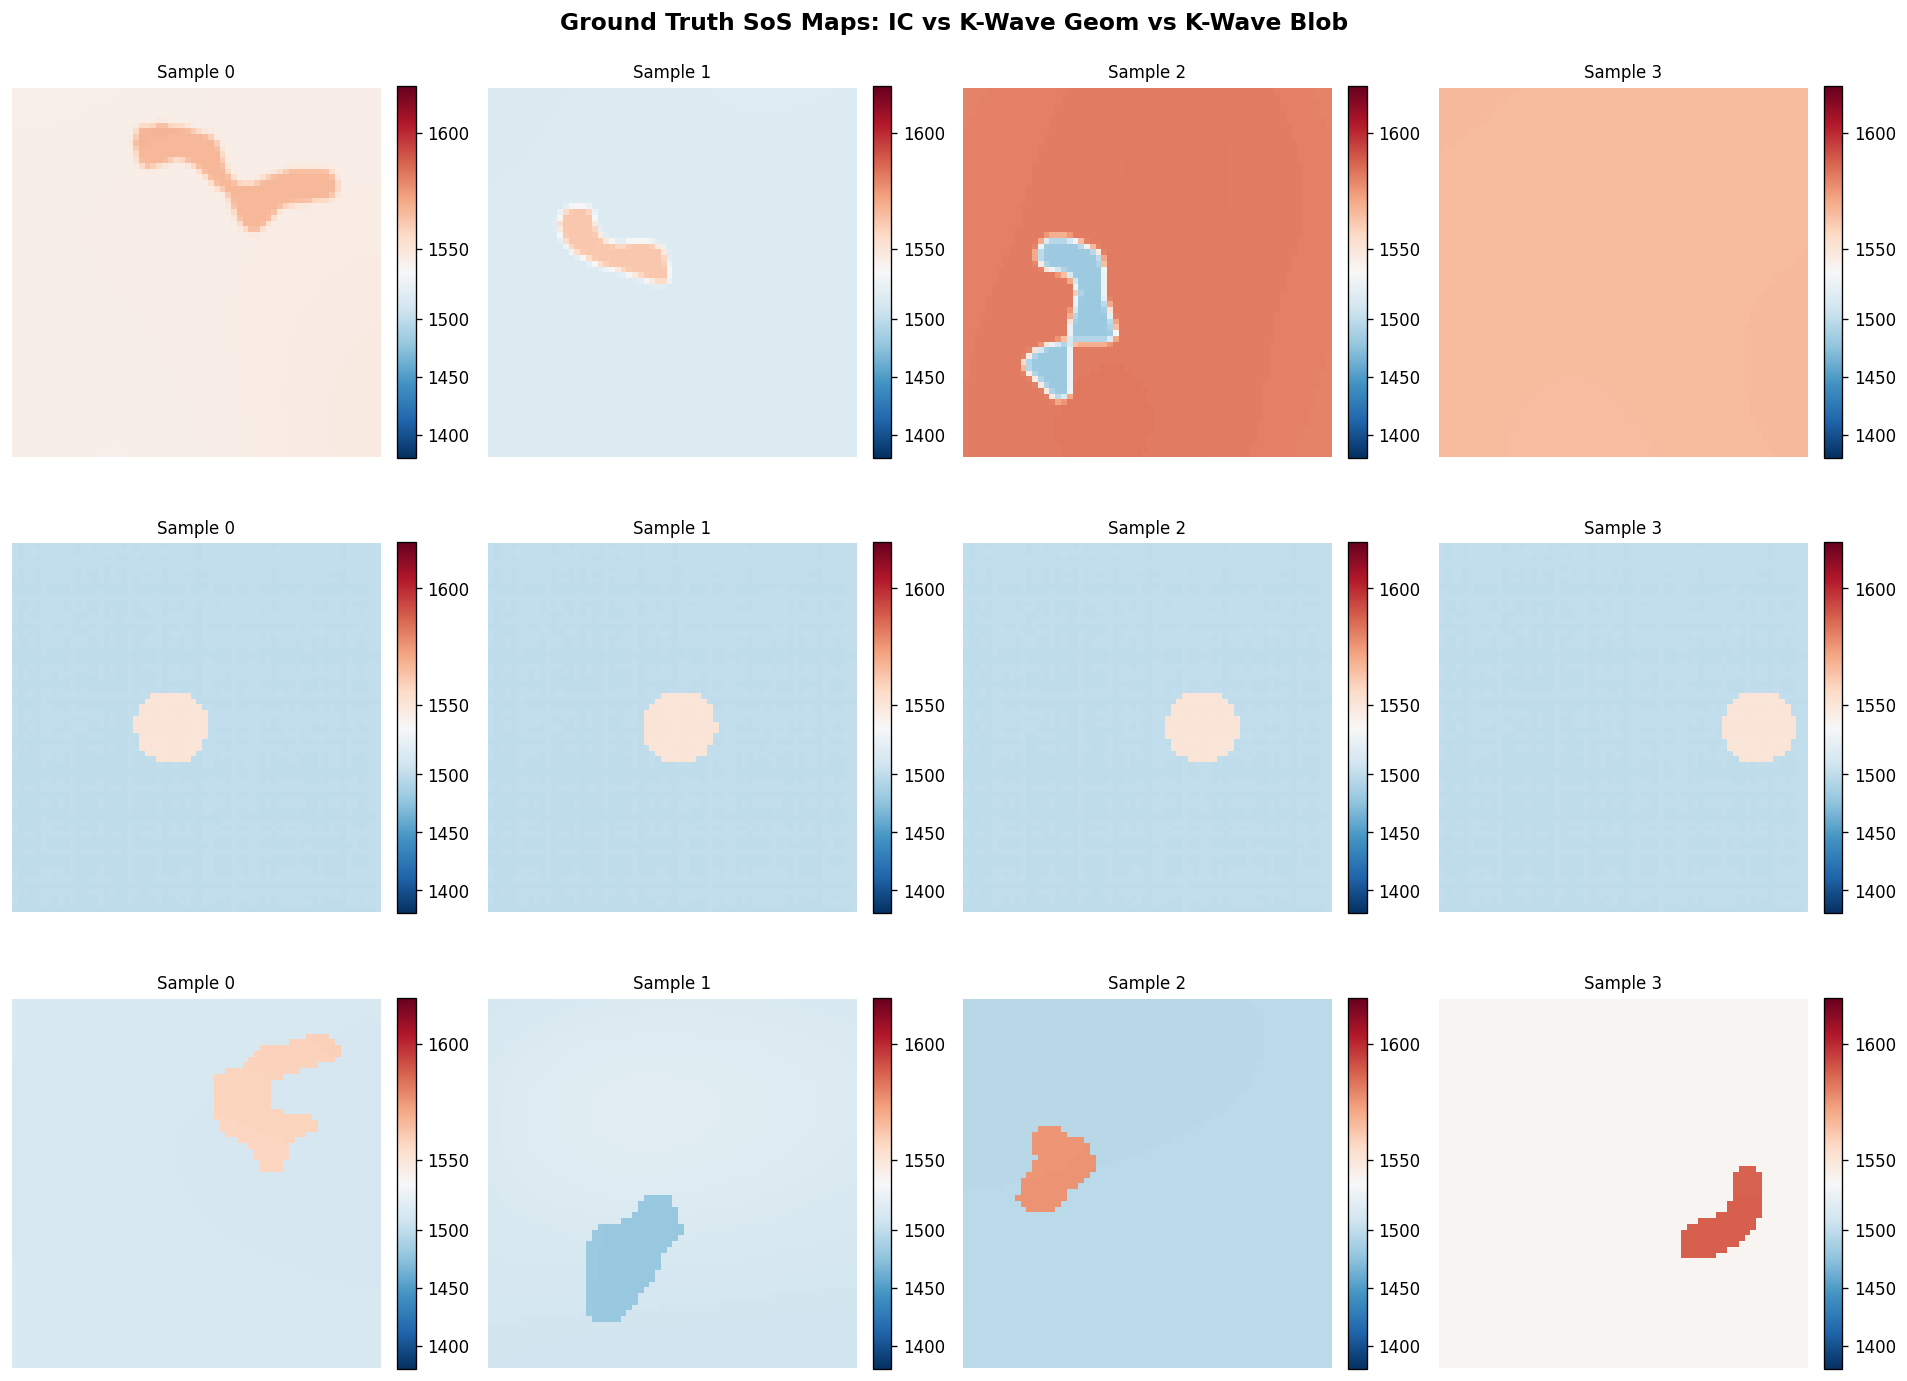

In [14]:
def slowness_to_sos(s):
    """Convert slowness (s/m) to speed of sound (m/s), handling edge cases."""
    s = np.clip(s, 1/1800, 1/1200)
    return 1.0 / s

def plot_gt_comparison(ic_data, kw_geom_data, kw_blob_data, indices, n_show=4):
    """Side-by-side GT comparison across three datasets."""
    fig, axes = plt.subplots(3, n_show, figsize=(4*n_show, 12))
    fig.suptitle("Ground Truth SoS Maps: IC vs K-Wave Geom vs K-Wave Blob", fontsize=14, fontweight='bold')
    
    norm = mcolors.TwoSlopeNorm(vmin=1380, vcenter=1540, vmax=1620)
    
    datasets = [
        ("Inverse Crime", ic_data),
        ("K-Wave Geom", kw_geom_data),
        ("K-Wave Blob", kw_blob_data),
    ]
    
    for row, (label, data) in enumerate(datasets):
        for col in range(n_show):
            ax = axes[row, col]
            gt = data['imgs_gt'][col]
            
            # Reshape — MATLAB column-major
            if gt.ndim == 1:
                img = gt.reshape(64, 64, order='F')
            elif gt.shape == (64, 64):
                img = gt
            elif gt.shape == (4096,):
                img = gt.reshape(64, 64, order='F')
            else:
                img = gt.squeeze()
                if img.ndim == 1:
                    img = img.reshape(64, 64, order='F')
            
            # Convert to SoS
            sos = slowness_to_sos(img)
            
            im = ax.imshow(sos, cmap='RdBu_r', norm=norm, interpolation='nearest')
            if col == 0:
                ax.set_ylabel(label, fontsize=12, fontweight='bold')
            ax.set_title(f"Sample {indices[col]}", fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

plot_gt_comparison(ic_data, kw_geom_data, kw_blob_data, sample_indices)

In [15]:
# GT statistics — contrast, dynamic range, inclusion properties
def gt_statistics(data, label):
    """Compute statistics over all GT samples."""
    imgs = data['imgs_gt']
    n = imgs.shape[0]
    
    stats = {'label': label, 'n_samples': n}
    
    all_sos = []
    contrasts = []
    for i in range(n):
        gt = imgs[i]
        if gt.ndim != 2 or gt.shape != (64, 64):
            gt = gt.flatten()
            gt = gt.reshape(64, 64, order='F') if len(gt) == 4096 else gt.reshape(64, 64)
        sos = slowness_to_sos(gt)
        all_sos.append(sos)
        
        # Estimate contrast: difference between inclusion and background
        bg = np.median(sos)
        deviation = np.abs(sos - bg)
        contrasts.append(deviation.max())
    
    all_sos = np.array(all_sos)
    stats['sos_mean'] = all_sos.mean()
    stats['sos_std'] = all_sos.std()
    stats['sos_min'] = all_sos.min()
    stats['sos_max'] = all_sos.max()
    stats['contrast_mean'] = np.mean(contrasts)
    stats['contrast_std'] = np.std(contrasts)
    stats['dynamic_range'] = all_sos.max() - all_sos.min()
    
    return stats

for path, label in [(IC_PATH, "IC"), (KWAVE_GEOM_PATH, "KW Geom"), (KWAVE_BLOB_PATH, "KW Blob")]:
    with h5py.File(path, 'r') as f:
        n = f['imgs_gt'].shape[0]
        all_indices = list(range(n))
    data_all = load_samples(path, all_indices, keys=('imgs_gt',))
    s = gt_statistics(data_all, label)
    print(f"\n{s['label']} ({s['n_samples']} samples):")
    print(f"  SoS range:   [{s['sos_min']:.1f}, {s['sos_max']:.1f}] m/s")
    print(f"  SoS mean:    {s['sos_mean']:.1f} ± {s['sos_std']:.1f} m/s")
    print(f"  Contrast:    {s['contrast_mean']:.1f} ± {s['contrast_std']:.1f} m/s (max dev from background)")
    print(f"  Dyn. range:  {s['dynamic_range']:.1f} m/s")


IC (10000 samples):
  SoS range:   [1396.9, 1651.4] m/s
  SoS mean:    1501.1 ± 57.8 m/s
  Contrast:    65.2 ± 53.7 m/s (max dev from background)
  Dyn. range:  254.5 m/s

KW Geom (32 samples):
  SoS range:   [1400.0, 1550.0] m/s
  SoS mean:    1502.0 ± 10.1 m/s
  Contrast:    45.0 ± 17.2 m/s (max dev from background)
  Dyn. range:  150.0 m/s

KW Blob (70 samples):
  SoS range:   [1415.0, 1617.8] m/s
  SoS mean:    1511.3 ± 53.4 m/s
  Contrast:    62.6 ± 38.0 m/s (max dev from background)
  Dyn. range:  202.8 m/s


## 3. Measurement Domain Analysis

Key question: How do IC measurements differ from k-wave measurements? IC measurements are generated exactly as d = L@s (no mismatch). K-wave measurements come from full-wave simulation.

In [16]:
# Measurement and mask statistics comparison
def measurement_stats(path, label, n_samples=None):
    """Compute measurement-domain statistics."""
    with h5py.File(path, 'r') as f:
        total = f['measmnts'].shape[0]
        n = n_samples or total
        indices = list(range(min(n, total)))
        
        all_d = []
        all_mask = []
        for i in indices:
            d = f['measmnts'][i].flatten()
            nan_mask = f['nanidx'][i].flatten()
            mask = 1.0 - nan_mask
            all_d.append(d)
            all_mask.append(mask)
    
    all_d = np.array(all_d)
    all_mask = np.array(all_mask)
    
    # Valid measurement stats
    valid_frac = all_mask.mean()
    
    # Distribution of valid measurements
    valid_d = all_d[all_mask > 0.5]
    valid_d = valid_d[~np.isnan(valid_d)]
    
    print(f"\n{label} ({len(indices)} samples, {all_d.shape[1]} rays/sample):")
    print(f"  Valid rays:  {valid_frac*100:.1f}% ({int(valid_frac * all_d.shape[1])}/{all_d.shape[1]})")
    print(f"  d_valid:     mean={valid_d.mean():.4e}  std={valid_d.std():.4e}")
    print(f"               min={valid_d.min():.4e}   max={valid_d.max():.4e}")
    print(f"               median={np.median(valid_d):.4e}")
    
    return all_d, all_mask

ic_d, ic_mask       = measurement_stats(IC_PATH, "IC", n_samples=32)
kw_geom_d, kw_geom_mask = measurement_stats(KWAVE_GEOM_PATH, "KW Geom")
kw_blob_d, kw_blob_mask = measurement_stats(KWAVE_BLOB_PATH, "KW Blob")


IC (32 samples, 131072 rays/sample):
  Valid rays:  56.9% (74627/131072)
  d_valid:     mean=2.5388e-09  std=3.7818e-07
               min=-1.1297e-06   max=1.1998e-06
               median=1.7842e-10

KW Geom (32 samples, 131072 rays/sample):
  Valid rays:  54.3% (71208/131072)
  d_valid:     mean=3.9668e-09  std=3.8419e-07
               min=-8.6793e-07   max=8.7002e-07
               median=2.6123e-09

KW Blob (70 samples, 131072 rays/sample):
  Valid rays:  47.2% (61812/131072)
  d_valid:     mean=5.6503e-10  std=3.6565e-07
               min=-8.6575e-07   max=8.7160e-07
               median=1.1413e-09


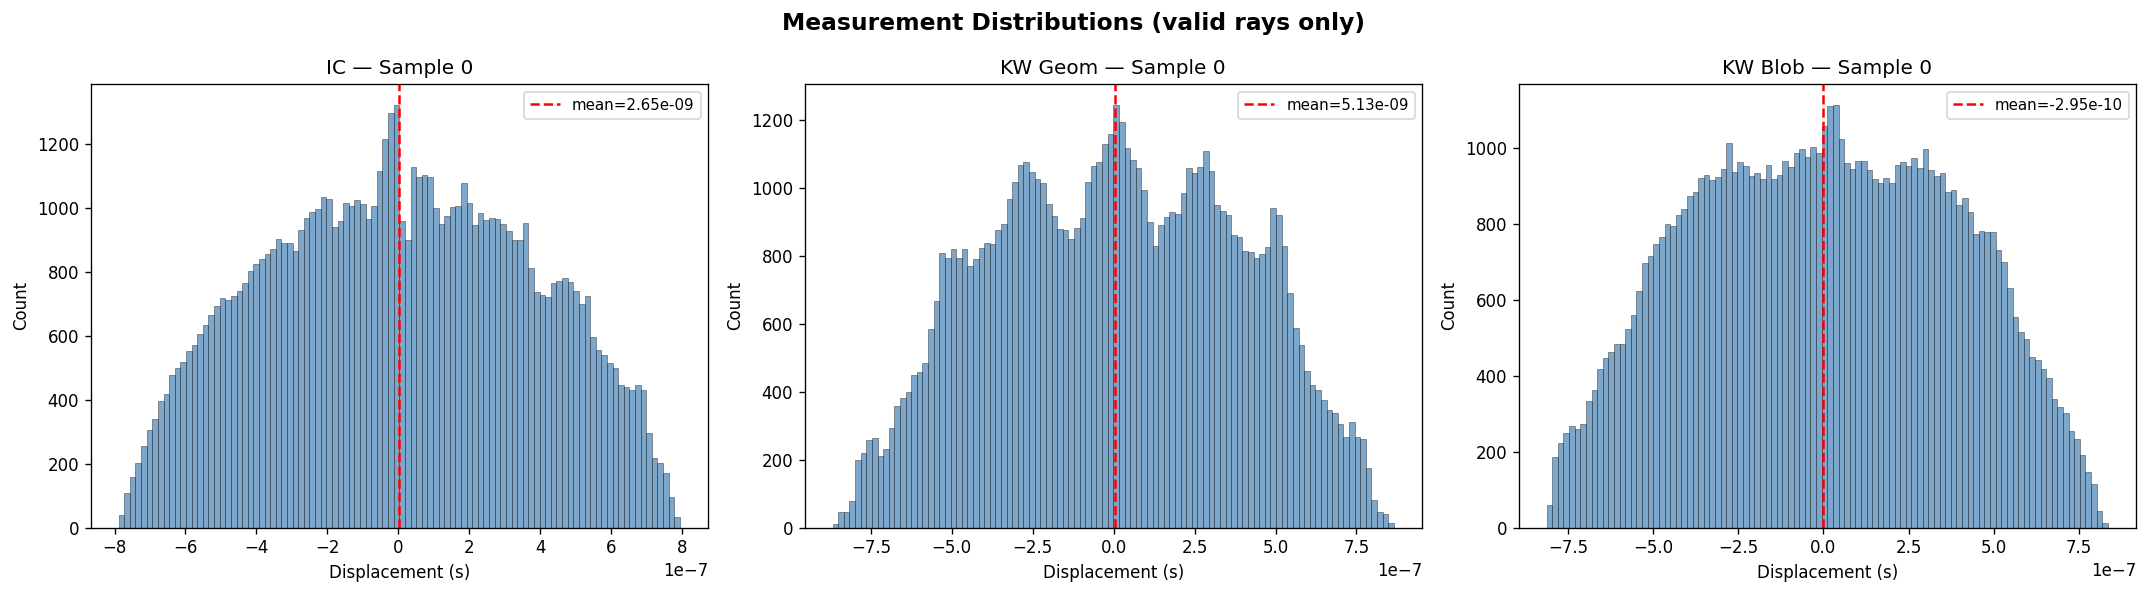

In [17]:
# Histogram comparison of measurement distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Measurement Distributions (valid rays only)", fontsize=14, fontweight='bold')

for ax, (d_arr, mask_arr, label) in zip(axes, [
    (ic_d, ic_mask, "IC"),
    (kw_geom_d, kw_geom_mask, "KW Geom"),
    (kw_blob_d, kw_blob_mask, "KW Blob"),
]):
    # Take sample 0 for histogram
    d0 = d_arr[0].flatten()
    m0 = mask_arr[0].flatten()
    valid = d0[m0 > 0.5]
    valid = valid[~np.isnan(valid)]
    
    ax.hist(valid, bins=100, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.3)
    ax.axvline(valid.mean(), color='red', linestyle='--', label=f'mean={valid.mean():.2e}')
    ax.set_title(f"{label} — Sample 0", fontsize=12)
    ax.set_xlabel("Displacement (s)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Mask Analysis — Ray Validity Patterns

The mask tells us which rays have valid measurements. On IC data, all rays are valid. On k-wave, many rays are invalid (NaN) because the full-wave simulation doesn't produce meaningful time-of-flight estimates for certain geometries. Understanding the spatial pattern of invalid rays is critical.

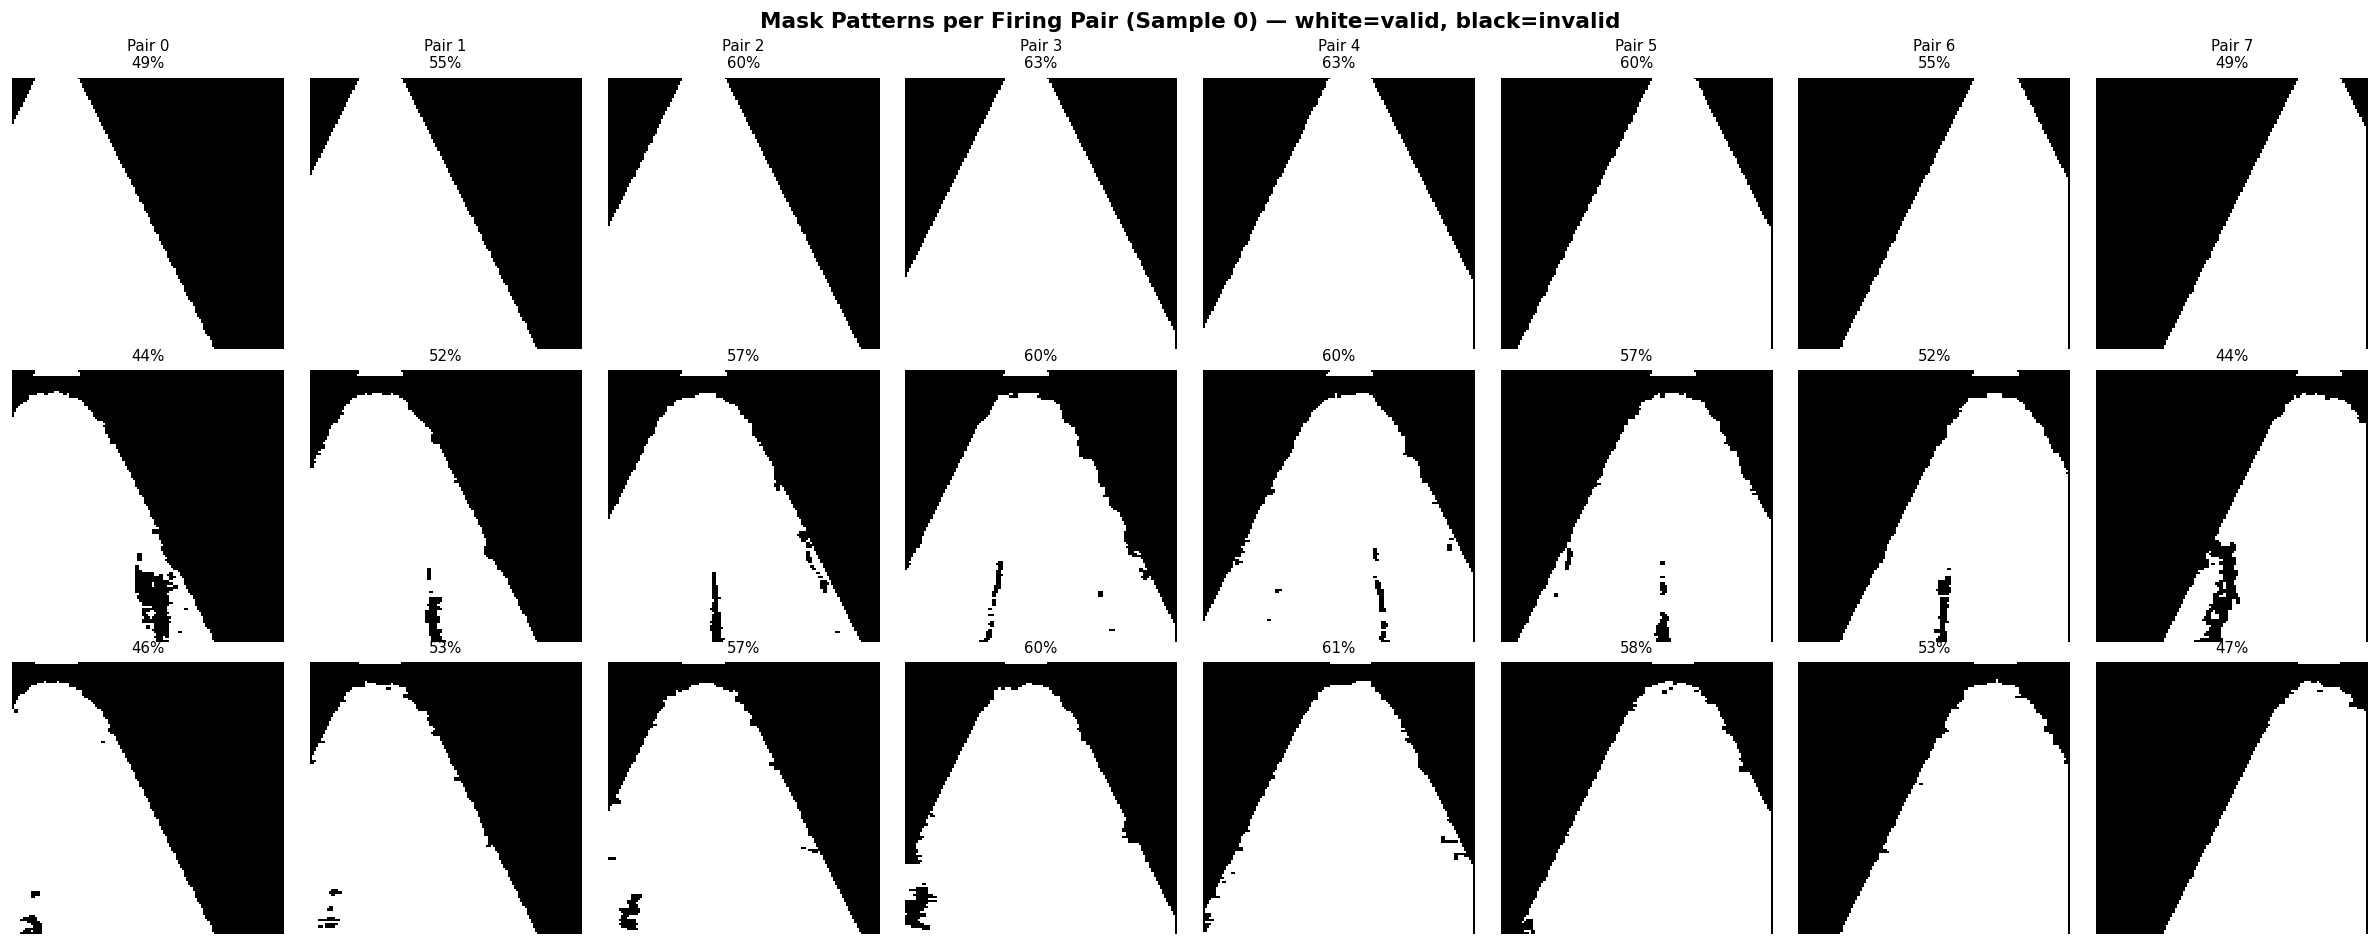

IC: valid rays = 56.9% ± 0.0%  (range: 56.9% - 56.9%)
KW Geom: valid rays = 54.3% ± 0.7%  (range: 51.3% - 54.7%)
KW Blob: valid rays = 47.2% ± 6.3%  (range: 28.9% - 54.8%)


In [25]:
# Mask patterns per firing pair
# 131072 = 128 * 128 * 8 firing pairs → each pair has 16384 rays

n_pairs = 8
pair_size = 131072 // n_pairs  # 16384

fig, axes = plt.subplots(3, n_pairs, figsize=(20, 8))
fig.suptitle("Mask Patterns per Firing Pair (Sample 0) — white=valid, black=invalid", 
             fontsize=13, fontweight='bold')

for row, (mask_arr, label) in enumerate([
    (ic_mask, "IC"),
    (kw_geom_mask, "KW Geom"),
    (kw_blob_mask, "KW Blob"),
]):
    m = mask_arr[0].flatten()
    for p in range(n_pairs):
        ax = axes[row, p]
        pair_mask = m[p * pair_size : (p + 1) * pair_size]
        # Reshape to 128x128
        pair_img = pair_mask.reshape(128, 128, order='F')
        ax.imshow(pair_img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        valid_pct = pair_mask.mean() * 100
        if row == 0:
            ax.set_title(f"Pair {p}\n{valid_pct:.0f}%", fontsize=9)
        else:
            ax.set_title(f"{valid_pct:.0f}%", fontsize=9)
        ax.axis('off')
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary: per-dataset mask stats
for mask_arr, label in [(ic_mask, "IC"), (kw_geom_mask, "KW Geom"), (kw_blob_mask, "KW Blob")]:
    valid_per_sample = mask_arr.mean(axis=1)
    print(f"{label}: valid rays = {valid_per_sample.mean()*100:.1f}% ± {valid_per_sample.std()*100:.1f}%"
          f"  (range: {valid_per_sample.min()*100:.1f}% - {valid_per_sample.max()*100:.1f}%)")

In [19]:
# Are mask patterns consistent across samples? (systematic vs sample-dependent)
# Compare mask of sample 0 vs sample 1 for kwave_geom

m0 = kw_geom_mask[0].flatten()
m1 = kw_geom_mask[1].flatten()
agreement = (m0 == m1).mean() * 100
same_invalid = ((m0 == 0) & (m1 == 0)).sum()
total_invalid_0 = (m0 == 0).sum()
total_invalid_1 = (m1 == 0).sum()

print(f"KW Geom mask agreement (sample 0 vs 1): {agreement:.1f}%")
print(f"  Invalid rays sample 0: {total_invalid_0}")
print(f"  Invalid rays sample 1: {total_invalid_1}")
print(f"  Shared invalid rays:   {same_invalid}")
print(f"  → {same_invalid/max(total_invalid_0,total_invalid_1)*100:.1f}% of invalid rays are shared"
      f" (systematic if high)")

# Check across all loaded samples
if kw_geom_mask.shape[0] > 2:
    masks = kw_geom_mask[:, :].reshape(kw_geom_mask.shape[0], -1)
    # Mask that is invalid for ALL samples
    all_invalid = (masks == 0).all(axis=0).sum()
    any_invalid = (masks == 0).any(axis=0).sum()
    print(f"\n  Always invalid (all {masks.shape[0]} samples): {all_invalid} rays")
    print(f"  Sometimes invalid (at least 1 sample):  {any_invalid} rays")
    print(f"  → {all_invalid/any_invalid*100:.1f}% of invalid rays are systematic (geometry-dependent)")

KW Geom mask agreement (sample 0 vs 1): 98.0%
  Invalid rays sample 0: 61100
  Invalid rays sample 1: 59971
  Shared invalid rays:   59196
  → 96.9% of invalid rays are shared (systematic if high)

  Always invalid (all 32 samples): 58498 rays
  Sometimes invalid (at least 1 sample):  69229 rays
  → 84.5% of invalid rays are systematic (geometry-dependent)


## 5. Forward Model Mismatch: ε = d_meas − L @ s_true

This is THE core question. On IC data, ε should be ~0 by construction. On k-wave, ε captures everything the ray-tracing L-matrix cannot model (diffraction, refraction, finite aperture effects, etc.).

In [26]:
def compute_mismatch(path, L, n_samples=None):
    """Compute ε = d_meas - L @ s_true for each sample.
    
    On IC data, ε ≈ 0 by construction (d_meas = L @ s_true).
    On k-wave data, ε captures everything the ray-tracing L cannot model.
    """
    with h5py.File(path, 'r') as f:
        total = f['imgs_gt'].shape[0]
        n = min(n_samples or total, total)
        
        results = []
        for i in range(n):
            s_gt = f['imgs_gt'][i].flatten()
            d_meas = f['measmnts'][i].flatten()
            d_meas = np.nan_to_num(d_meas, nan=0.0)
            mask = 1.0 - f['nanidx'][i].flatten()
            
            # Forward model prediction using GT slowness
            d_pred = L @ s_gt
            
            # Mismatch on valid rays only
            epsilon = (d_meas - d_pred) * mask
            
            valid_eps = epsilon[mask > 0.5]
            valid_d = d_meas[mask > 0.5]
            
            # Energy ratio: ||ε||² / ||d_meas||²
            eps_energy = np.sum(valid_eps**2)
            d_energy = np.sum(valid_d**2)
            energy_ratio = eps_energy / (d_energy + 1e-30)
            
            results.append({
                'epsilon': epsilon,
                'mask': mask,
                'eps_mae': np.mean(np.abs(valid_eps)),
                'eps_rmse': np.sqrt(np.mean(valid_eps**2)),
                'eps_energy_pct': energy_ratio * 100,
                'd_energy': d_energy,
                'n_valid': mask.sum(),
            })
    return results

# Same L-matrix for all datasets (confirmed above)
print("Computing mismatch for IC (expect ε ≈ 0)...")
ic_mismatch = compute_mismatch(IC_PATH, L, n_samples=32)

print("Computing mismatch for KW Geom (32 samples)...")
kw_geom_mismatch = compute_mismatch(KWAVE_GEOM_PATH, L)

print("Computing mismatch for KW Blob (70 samples)...")
kw_blob_mismatch = compute_mismatch(KWAVE_BLOB_PATH, L)

# Summary table
print(f"\n{'Dataset':<15} {'ε MAE':>12} {'ε RMSE':>12} {'ε Energy %':>12} {'n_valid':>10}")
print("-" * 65)
for label, mismatch in [("IC", ic_mismatch), ("KW Geom", kw_geom_mismatch), ("KW Blob", kw_blob_mismatch)]:
    mae  = np.mean([m['eps_mae'] for m in mismatch])
    rmse = np.mean([m['eps_rmse'] for m in mismatch])
    epct = np.mean([m['eps_energy_pct'] for m in mismatch])
    nval = np.mean([m['n_valid'] for m in mismatch])
    print(f"{label:<15} {mae:>12.4e} {rmse:>12.4e} {epct:>12.2f}% {nval:>10.0f}")

Computing mismatch for IC (expect ε ≈ 0)...
Computing mismatch for KW Geom (32 samples)...
Computing mismatch for KW Blob (70 samples)...

Dataset                ε MAE       ε RMSE   ε Energy %    n_valid
-----------------------------------------------------------------
IC                3.4203e-09   7.9911e-09         0.06%      74627
KW Geom           8.0932e-09   1.2073e-08         0.11%      71208
KW Blob           1.4067e-08   2.1549e-08         0.44%      61812


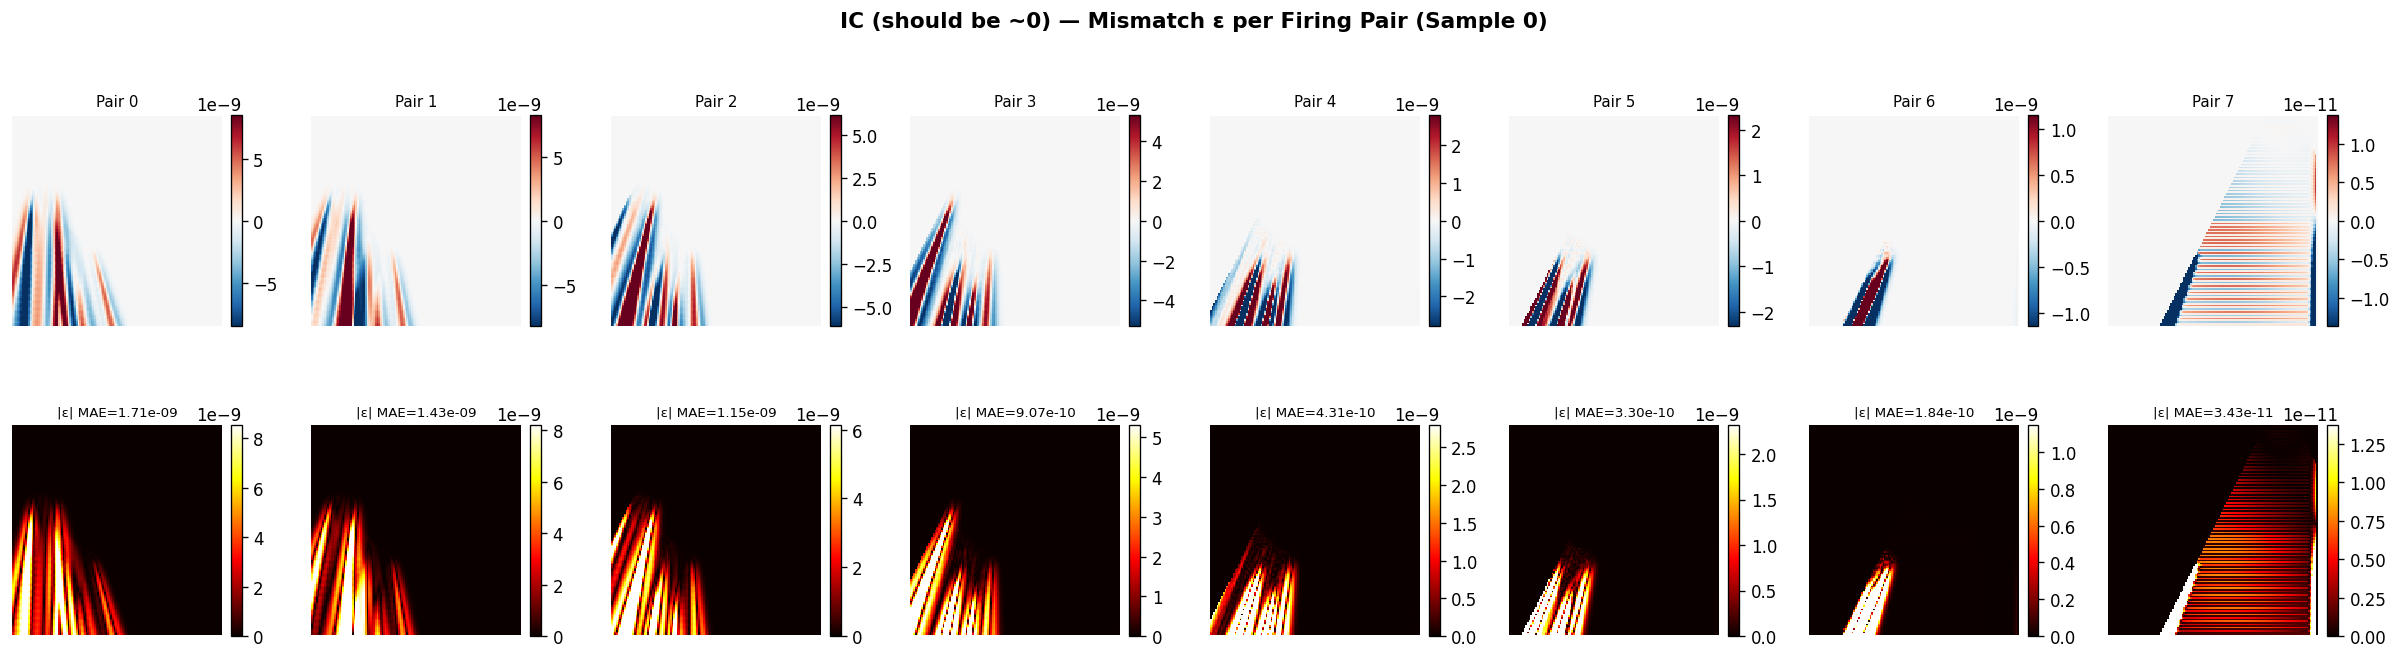

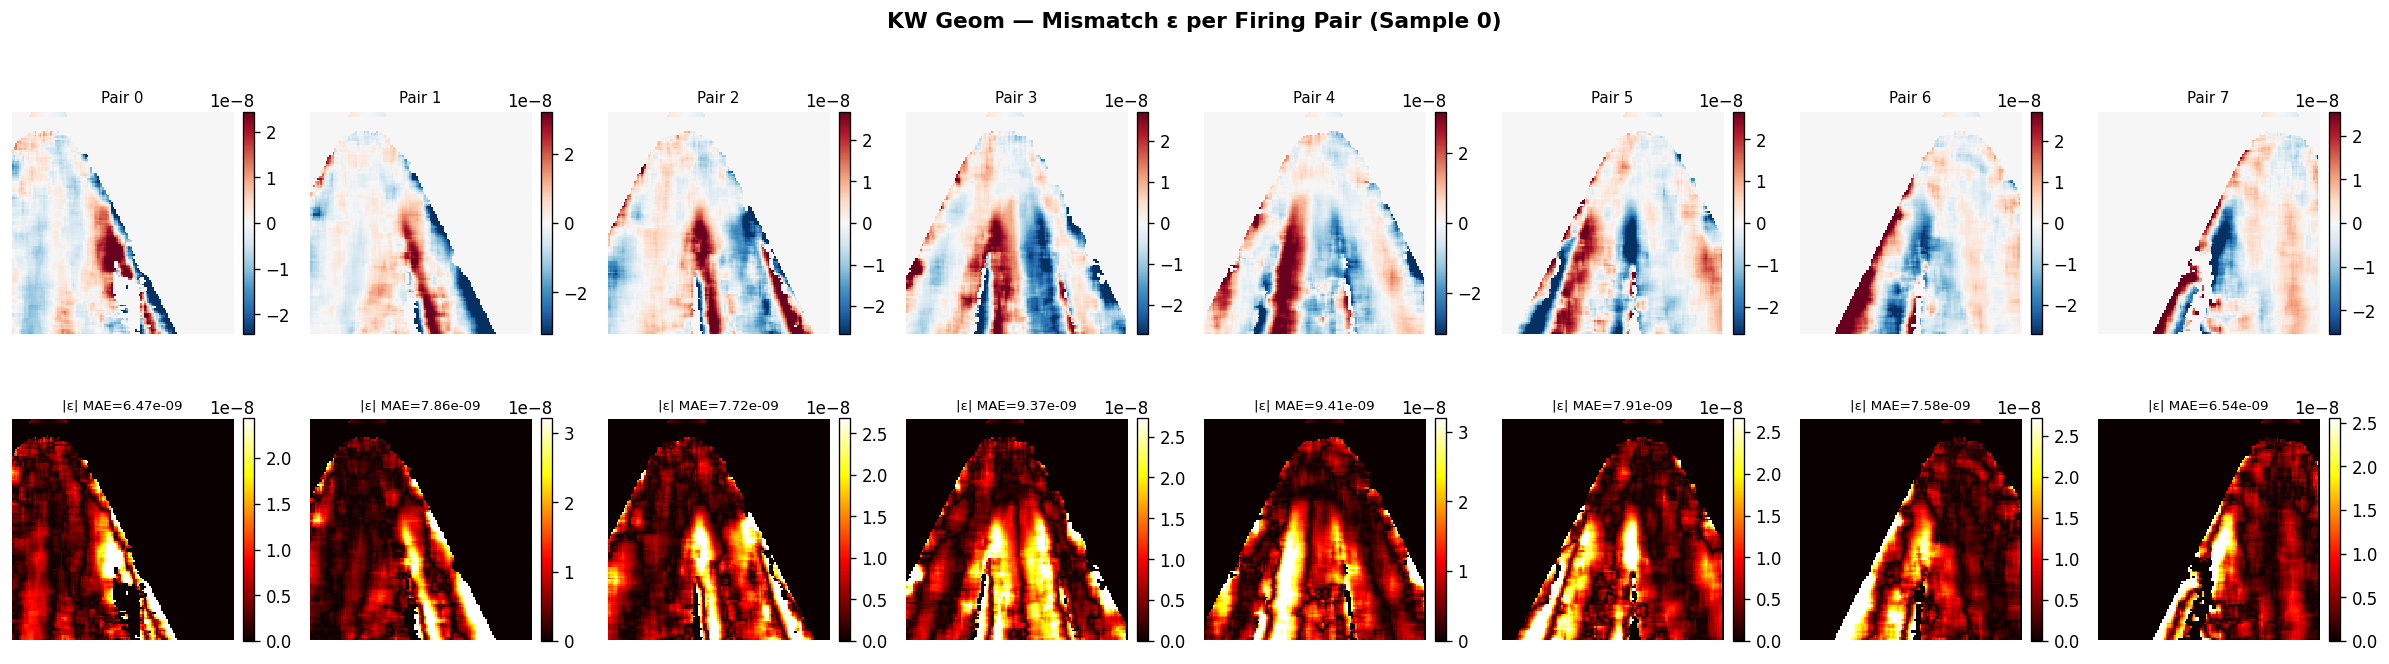

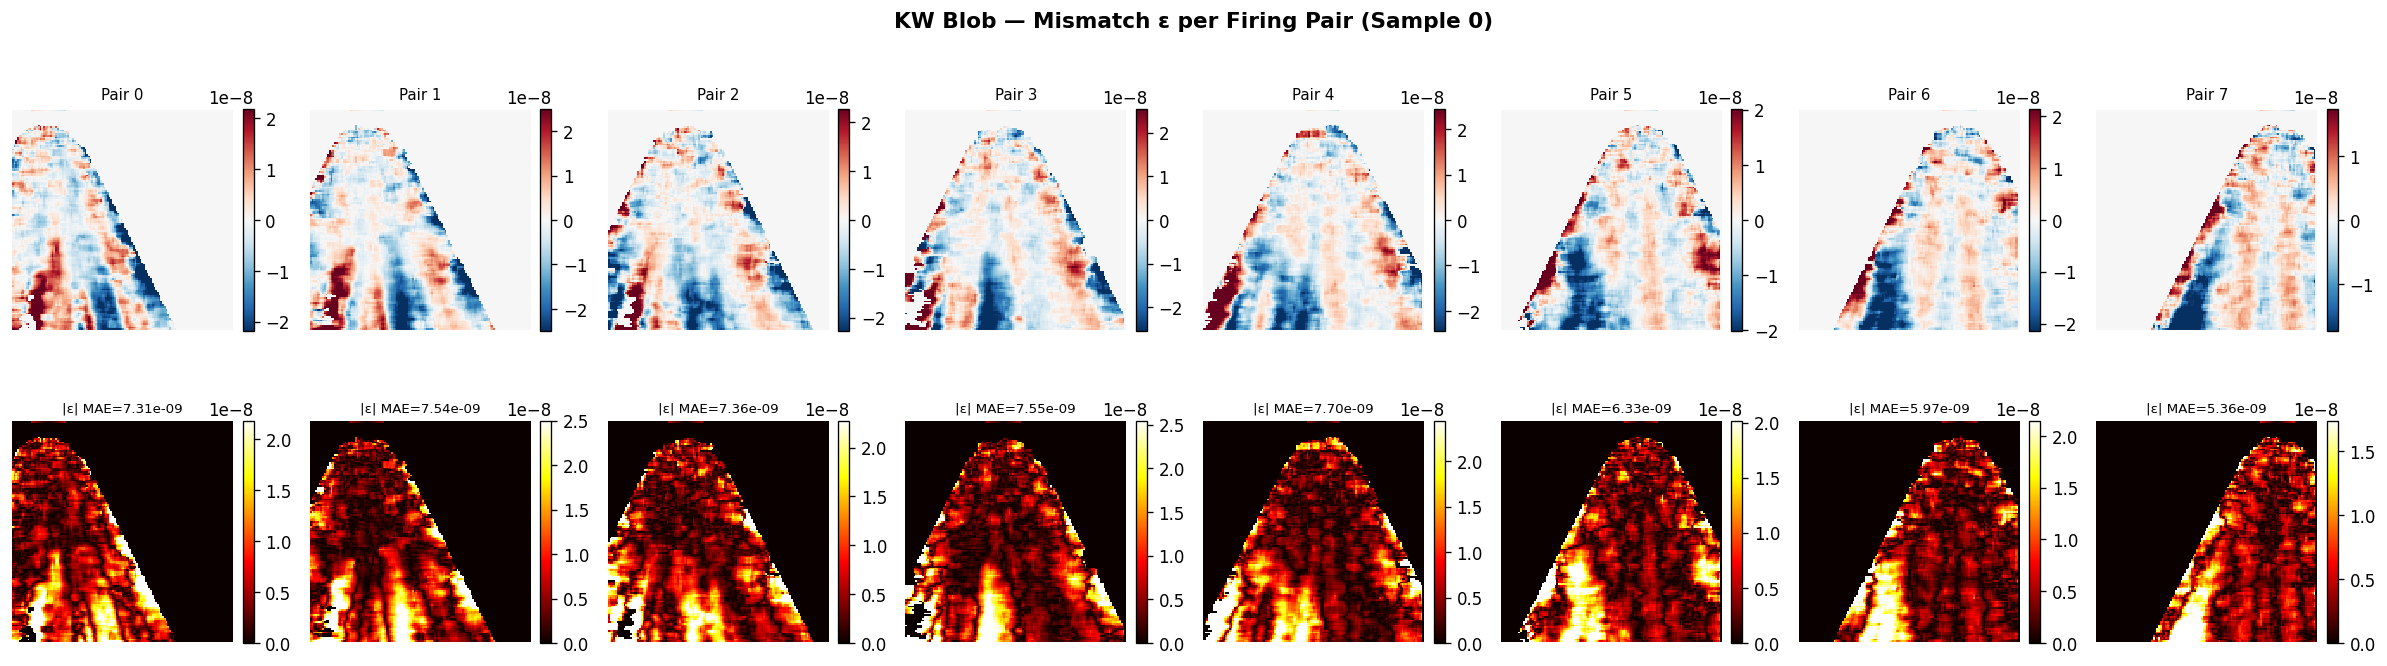

In [27]:
# Visualize mismatch ε per firing pair for one k-wave sample
def plot_mismatch_per_pair(mismatch_result, label, sample_idx=0):
    """Visualize ε reshaped into firing-pair images."""
    eps = mismatch_result[sample_idx]['epsilon']
    mask = mismatch_result[sample_idx]['mask']
    
    pair_size = len(eps) // n_pairs
    
    fig, axes = plt.subplots(2, n_pairs, figsize=(20, 6))
    fig.suptitle(f"{label} — Mismatch ε per Firing Pair (Sample {sample_idx})", 
                 fontsize=13, fontweight='bold')
    
    for p in range(n_pairs):
        sl = slice(p * pair_size, (p + 1) * pair_size)
        eps_pair = eps[sl]
        mask_pair = mask[sl]
        
        # Reshape to 128x128 (MATLAB column-major)
        eps_img = eps_pair.reshape(128, 128, order='F')
        mask_img = mask_pair.reshape(128, 128, order='F')
        
        # Top row: raw epsilon
        vmax = np.percentile(np.abs(eps_pair[mask_pair > 0.5]), 95) if mask_pair.sum() > 0 else 1e-7
        im = axes[0, p].imshow(eps_img, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
        axes[0, p].set_title(f"Pair {p}", fontsize=9)
        axes[0, p].axis('off')
        plt.colorbar(im, ax=axes[0, p], fraction=0.046, pad=0.04)
        
        # Bottom row: absolute epsilon (masked)
        abs_eps = np.abs(eps_img) * mask_img
        im2 = axes[1, p].imshow(abs_eps, cmap='hot', vmin=0, vmax=vmax, interpolation='nearest')
        valid_mae = np.mean(np.abs(eps_pair[mask_pair > 0.5])) if mask_pair.sum() > 0 else 0
        axes[1, p].set_title(f"|ε| MAE={valid_mae:.2e}", fontsize=8)
        axes[1, p].axis('off')
        plt.colorbar(im2, ax=axes[1, p], fraction=0.046, pad=0.04)
    
    axes[0, 0].set_ylabel("ε (signed)", fontsize=10)
    axes[1, 0].set_ylabel("|ε|", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_mismatch_per_pair(ic_mismatch, "IC (should be ~0)")
plot_mismatch_per_pair(kw_geom_mismatch, "KW Geom")
plot_mismatch_per_pair(kw_blob_mismatch, "KW Blob")

In [28]:
# Is mismatch systematic across samples? (template analysis)
# Compare ε of sample 0 vs sample 1 — if correlated, mismatch is geometry-dependent, not noise

def mismatch_cross_sample_correlation(mismatch_list, label):
    """Check if ε is consistent across samples (systematic vs random)."""
    n = len(mismatch_list)
    if n < 2:
        return
    
    # Stack all epsilon vectors (masked)
    eps_stack = []
    common_mask = mismatch_list[0]['mask'].copy()
    for m in mismatch_list:
        common_mask *= m['mask']  # intersection of valid rays
    
    valid_idx = common_mask > 0.5
    n_common = valid_idx.sum()
    
    for m in mismatch_list:
        eps_stack.append(m['epsilon'][valid_idx])
    
    eps_stack = np.array(eps_stack)  # (n_samples, n_common_valid_rays)
    
    # Mean mismatch template
    template = eps_stack.mean(axis=0)
    
    # Per-sample correlation with template
    corrs = []
    for i in range(n):
        r = np.corrcoef(eps_stack[i], template)[0, 1]
        corrs.append(r)
    
    # Leave-one-out: how well does mean-of-others predict each sample?
    loo_corrs = []
    for i in range(n):
        others = np.delete(eps_stack, i, axis=0)
        loo_template = others.mean(axis=0)
        r = np.corrcoef(eps_stack[i], loo_template)[0, 1]
        loo_corrs.append(r)
    
    print(f"\n{label} — Cross-sample mismatch analysis ({n} samples, {n_common} common valid rays):")
    print(f"  Correlation with mean template: {np.mean(corrs):.4f} ± {np.std(corrs):.4f}")
    print(f"  Leave-one-out correlation:      {np.mean(loo_corrs):.4f} ± {np.std(loo_corrs):.4f}")
    print(f"  → {'SYSTEMATIC' if np.mean(loo_corrs) > 0.5 else 'RANDOM'} mismatch")
    
    return template, eps_stack

ic_template, _ = mismatch_cross_sample_correlation(ic_mismatch, "IC")
kw_geom_template, kw_geom_eps_stack = mismatch_cross_sample_correlation(kw_geom_mismatch, "KW Geom")
kw_blob_template, kw_blob_eps_stack = mismatch_cross_sample_correlation(kw_blob_mismatch, "KW Blob")


IC — Cross-sample mismatch analysis (32 samples, 74627 common valid rays):
  Correlation with mean template: 0.1697 ± 0.1302
  Leave-one-out correlation:      0.0280 ± 0.1024
  → RANDOM mismatch

KW Geom — Cross-sample mismatch analysis (32 samples, 61843 common valid rays):
  Correlation with mean template: 0.6844 ± 0.1611
  Leave-one-out correlation:      0.6568 ± 0.1778
  → SYSTEMATIC mismatch

KW Blob — Cross-sample mismatch analysis (70 samples, 4927 common valid rays):
  Correlation with mean template: 0.3364 ± 0.1658
  Leave-one-out correlation:      0.2964 ± 0.1742
  → RANDOM mismatch


/tmp/ipykernel_3079917/1251492780.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([pair_energies[:, p] for p in range(n_pairs)], labels=[f"P{p}" for p in range(n_pairs)])
/tmp/ipykernel_3079917/1251492780.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([pair_maes[:, p] for p in range(n_pairs)], labels=[f"P{p}" for p in range(n_pairs)])


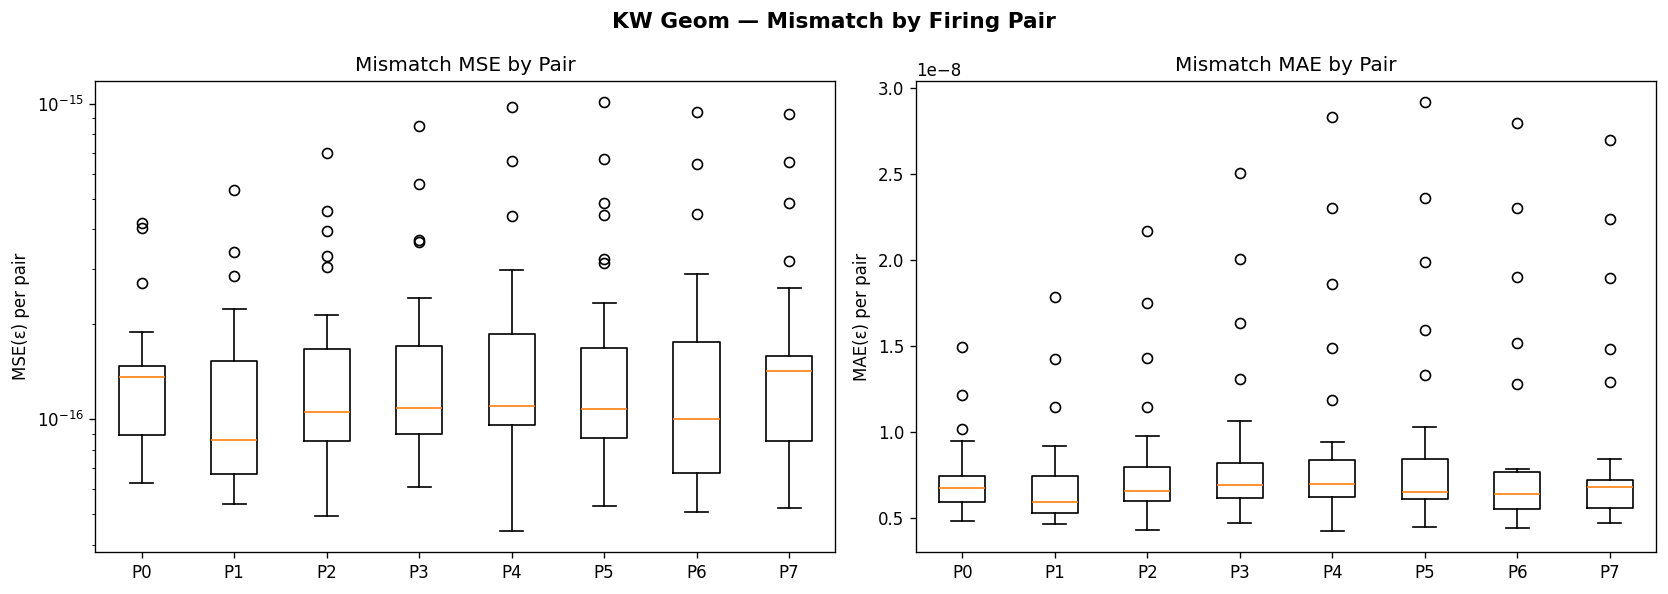

  Per-pair MAE: ['7.11e-09', '6.98e-09', '7.87e-09', '8.35e-09', '8.72e-09', '8.83e-09', '8.24e-09', '8.34e-09']
  Ratio max/min: 1.3x


/tmp/ipykernel_3079917/1251492780.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([pair_energies[:, p] for p in range(n_pairs)], labels=[f"P{p}" for p in range(n_pairs)])
/tmp/ipykernel_3079917/1251492780.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([pair_maes[:, p] for p in range(n_pairs)], labels=[f"P{p}" for p in range(n_pairs)])


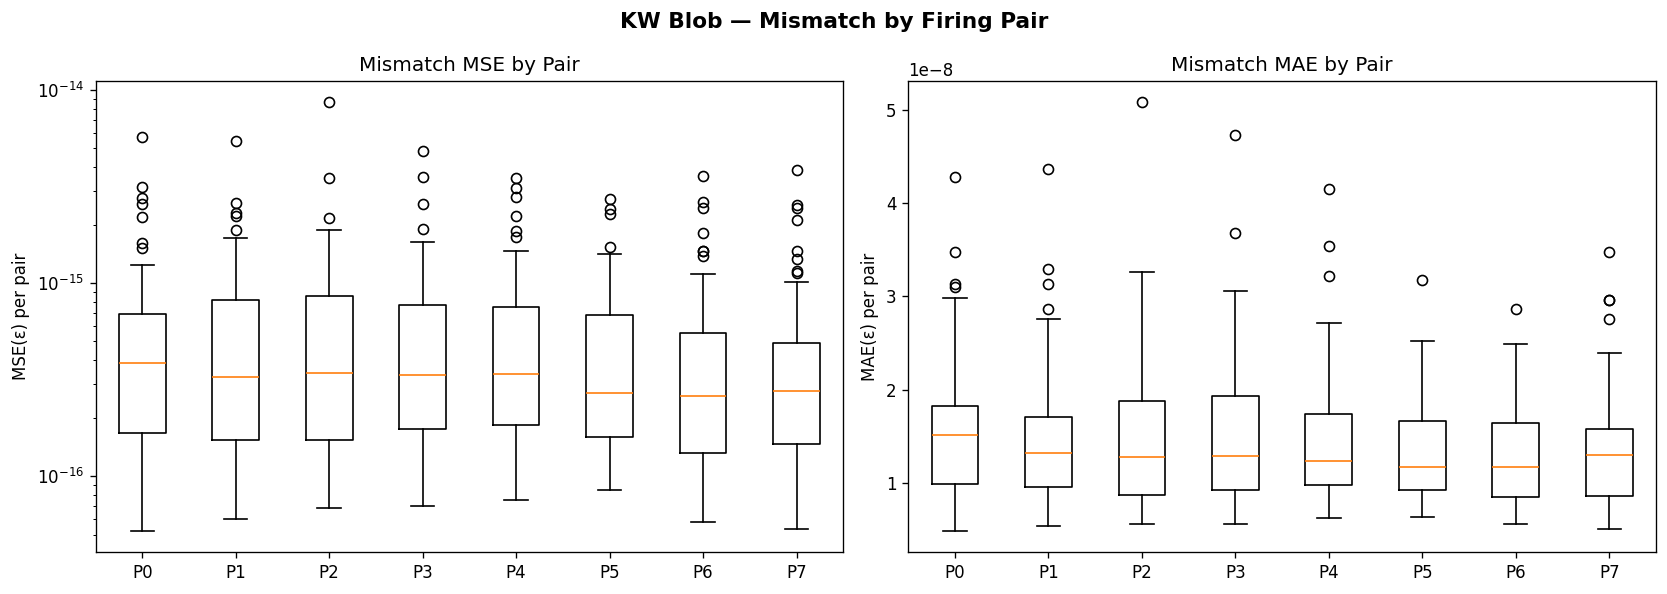

  Per-pair MAE: ['1.55e-08', '1.48e-08', '1.50e-08', '1.49e-08', '1.44e-08', '1.31e-08', '1.29e-08', '1.36e-08']
  Ratio max/min: 1.2x


In [30]:
# Mismatch energy as a function of firing pair
# Does some pairs have more mismatch than others?

def mismatch_per_pair_energy(mismatch_list, label):
    """Break down mismatch energy by firing pair."""
    pair_size = 131072 // n_pairs
    
    pair_energies = np.zeros((len(mismatch_list), n_pairs))
    pair_maes = np.zeros((len(mismatch_list), n_pairs))
    
    for i, m in enumerate(mismatch_list):
        eps = m['epsilon']
        mask = m['mask']
        for p in range(n_pairs):
            sl = slice(p * pair_size, (p + 1) * pair_size)
            valid = mask[sl] > 0.5
            if valid.sum() > 0:
                pair_energies[i, p] = np.sum(eps[sl][valid]**2) / valid.sum()
                pair_maes[i, p] = np.mean(np.abs(eps[sl][valid]))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{label} — Mismatch by Firing Pair", fontsize=13, fontweight='bold')
    
    # Box plot of per-pair MSE
    ax1.boxplot([pair_energies[:, p] for p in range(n_pairs)], labels=[f"P{p}" for p in range(n_pairs)])
    ax1.set_ylabel("MSE(ε) per pair")
    ax1.set_title("Mismatch MSE by Pair")
    ax1.set_yscale('log')
    
    # Box plot of per-pair MAE
    ax2.boxplot([pair_maes[:, p] for p in range(n_pairs)], labels=[f"P{p}" for p in range(n_pairs)])
    ax2.set_ylabel("MAE(ε) per pair")
    ax2.set_title("Mismatch MAE by Pair")
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    mean_mae = pair_maes.mean(axis=0)
    print(f"  Per-pair MAE: {['%.2e' % m for m in mean_mae]}")
    print(f"  Ratio max/min: {mean_mae.max()/mean_mae.min():.1f}x")

mismatch_per_pair_energy(kw_geom_mismatch, "KW Geom")
mismatch_per_pair_energy(kw_blob_mismatch, "KW Blob")

## 6. L1/L2 Baseline Comparison

K-wave datasets include pre-computed L1 (LASSO) and L2 (Tikhonov) baseline reconstructions. These represent what classical linear inverse methods can achieve. Understanding *how* they succeed (and where they fail) guides what INR needs to do differently.

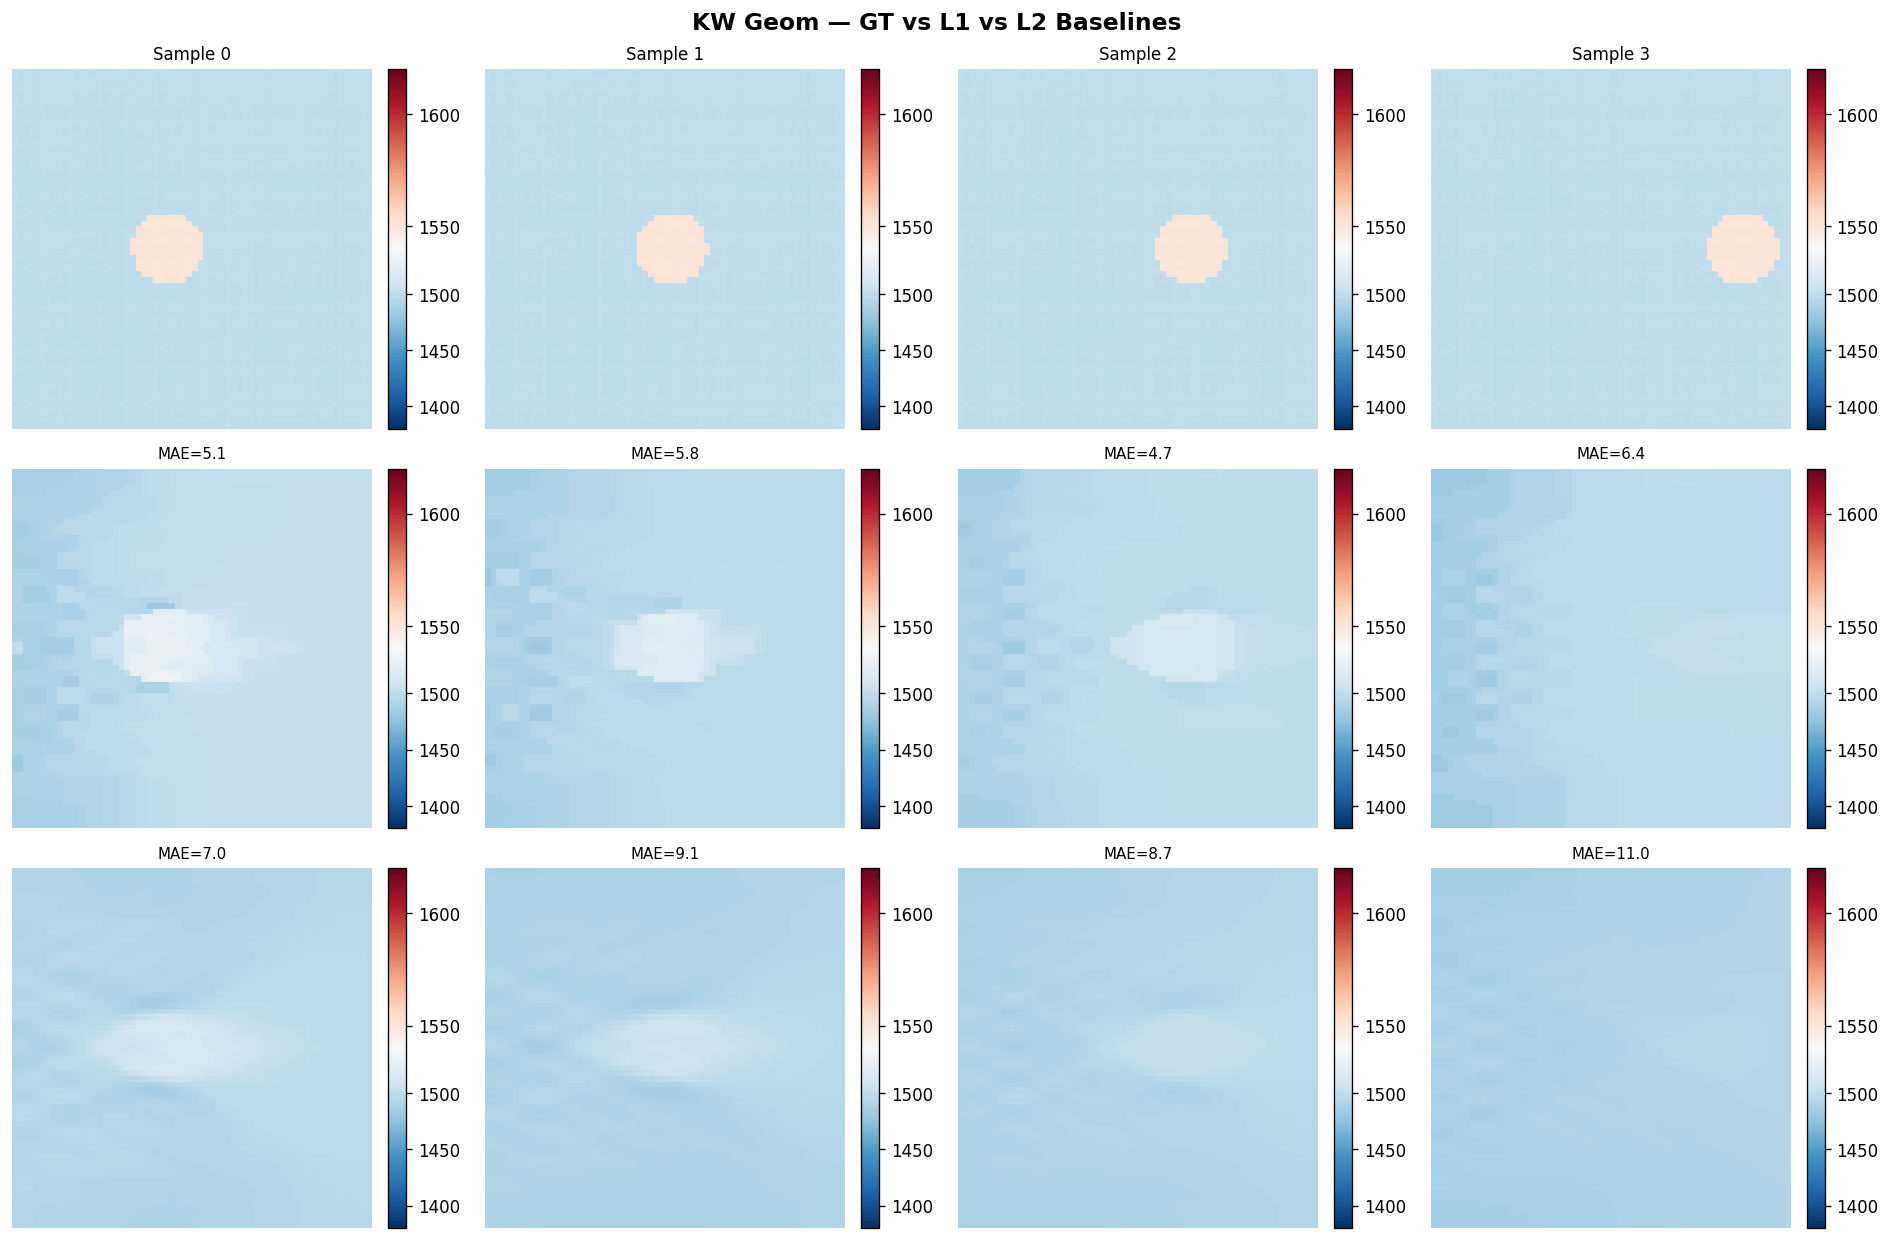

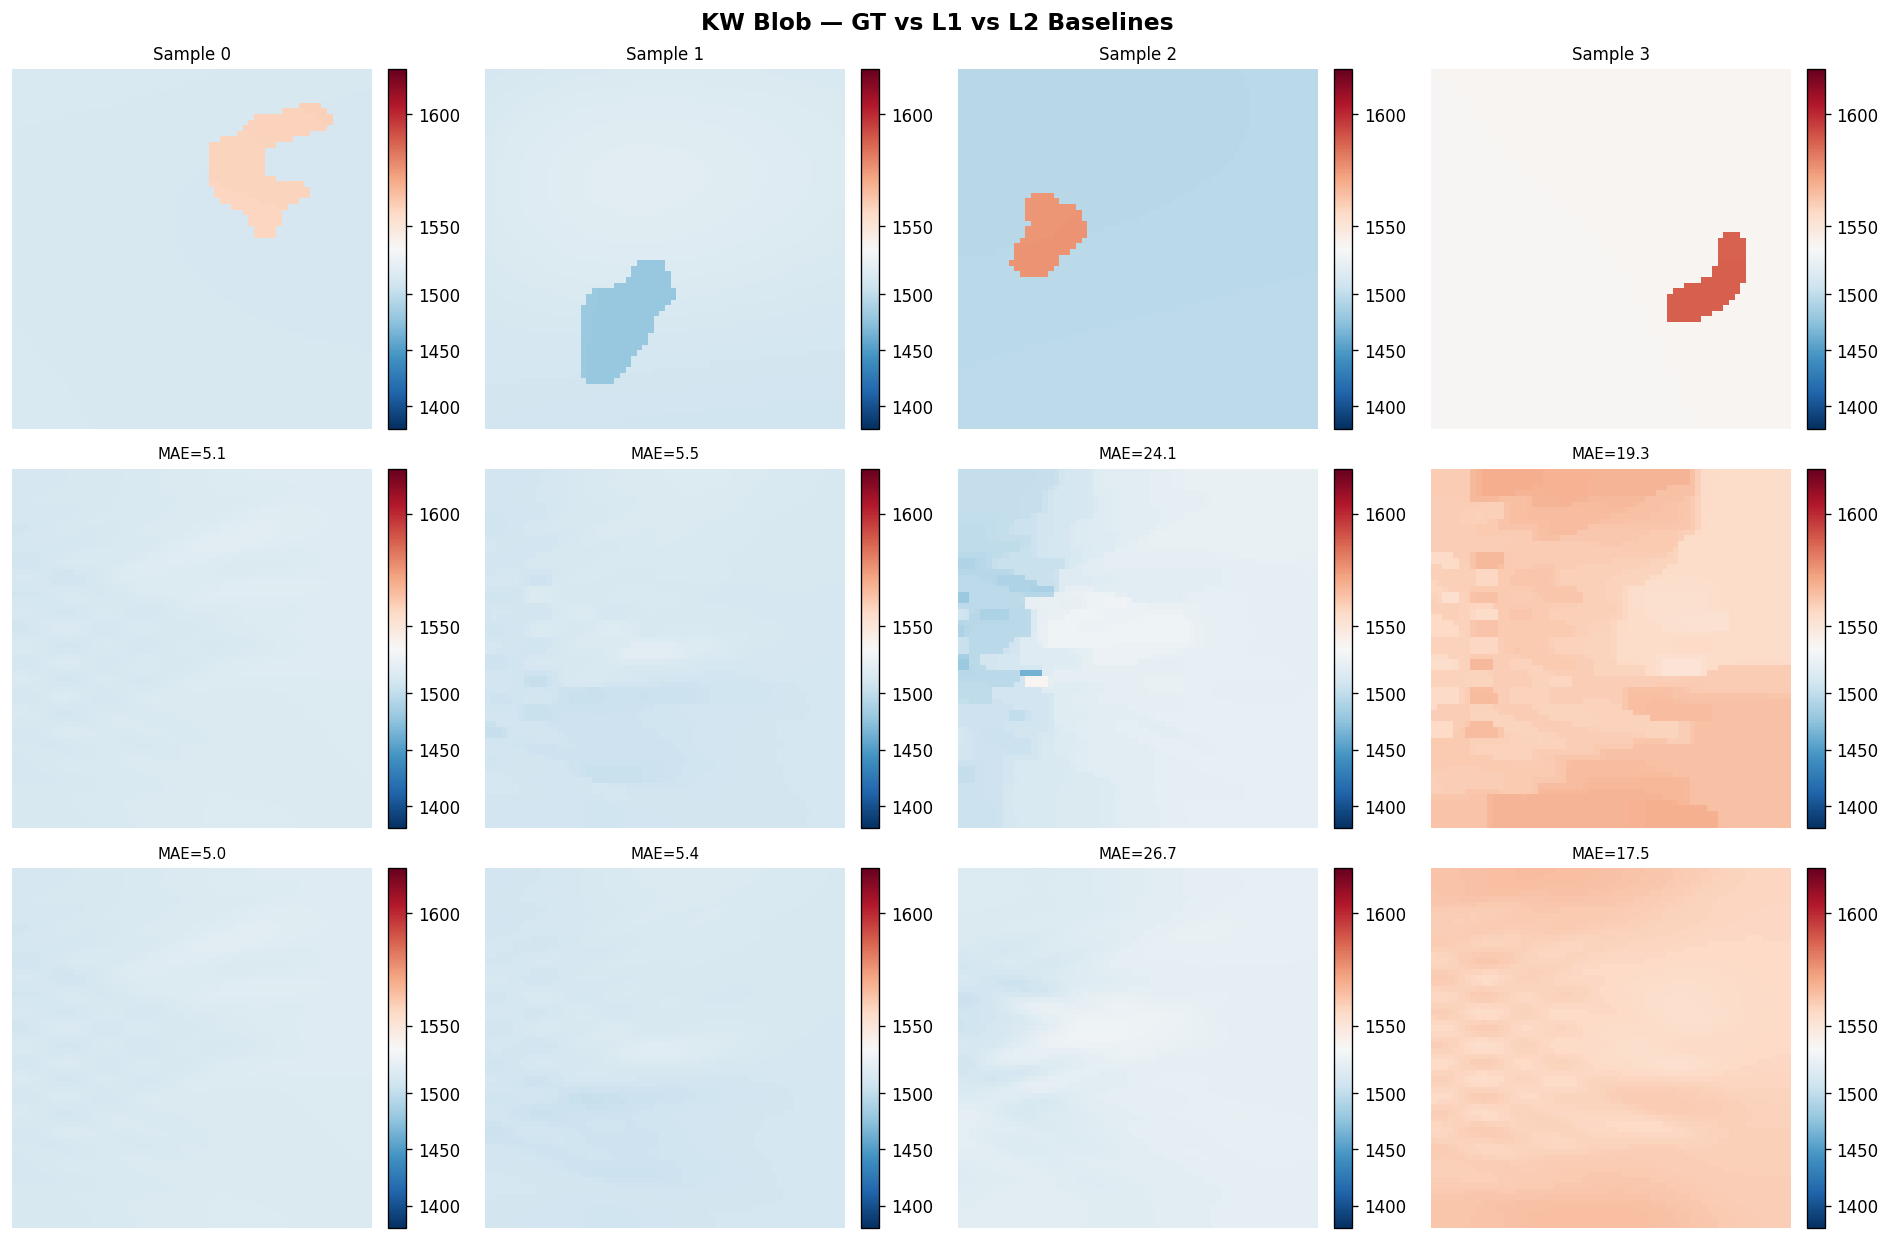

In [31]:
# Compare GT vs L1 vs L2 for kwave_geom
def to_2d(arr):
    """Safely get a (64,64) image from whatever shape the data is in."""
    if arr.shape == (64, 64):
        return arr
    flat = arr.flatten()
    # Already confirmed: 3D HDF5 arrays (N,64,64) → each slice is correct as-is
    # Only use order='F' if we get a raw 1D vector (e.g. from flattened MATLAB data)
    return flat.reshape(64, 64)

def plot_baseline_comparison(data, indices, dataset_label, n_show=4):
    """GT | L1 recon | L2 recon"""
    has_l1 = 'all_slowness_recons_l1' in data
    has_l2 = 'all_slowness_recons_l2' in data
    
    if not (has_l1 or has_l2):
        print(f"No baselines available for {dataset_label}")
        return
    
    n_rows = 3  # GT, L1, L2
    fig, axes = plt.subplots(n_rows, n_show, figsize=(4*n_show, 3.5*n_rows))
    fig.suptitle(f"{dataset_label} — GT vs L1 vs L2 Baselines", fontsize=14, fontweight='bold')
    
    norm = mcolors.TwoSlopeNorm(vmin=1380, vcenter=1540, vmax=1620)
    
    for col in range(n_show):
        gt_sos = slowness_to_sos(to_2d(data['imgs_gt'][col]))
        
        im = axes[0, col].imshow(gt_sos, cmap='RdBu_r', norm=norm, interpolation='nearest')
        axes[0, col].set_title(f"Sample {indices[col]}", fontsize=10)
        axes[0, col].axis('off')
        if col == 0:
            axes[0, col].set_ylabel("GT", fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)
        
        if has_l1:
            l1_sos = slowness_to_sos(to_2d(data['all_slowness_recons_l1'][col]))
            mae_l1 = np.mean(np.abs(gt_sos - l1_sos))
            im = axes[1, col].imshow(l1_sos, cmap='RdBu_r', norm=norm, interpolation='nearest')
            axes[1, col].set_title(f"MAE={mae_l1:.1f}", fontsize=9)
            axes[1, col].axis('off')
            if col == 0:
                axes[1, col].set_ylabel("L1 (LASSO)", fontsize=11, fontweight='bold')
            plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)
        
        if has_l2:
            l2_sos = slowness_to_sos(to_2d(data['all_slowness_recons_l2'][col]))
            mae_l2 = np.mean(np.abs(gt_sos - l2_sos))
            im = axes[2, col].imshow(l2_sos, cmap='RdBu_r', norm=norm, interpolation='nearest')
            axes[2, col].set_title(f"MAE={mae_l2:.1f}", fontsize=9)
            axes[2, col].axis('off')
            if col == 0:
                axes[2, col].set_ylabel("L2 (Tikhonov)", fontsize=11, fontweight='bold')
            plt.colorbar(im, ax=axes[2, col], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

plot_baseline_comparison(kw_geom_data, sample_indices, "KW Geom")
plot_baseline_comparison(kw_blob_data, sample_indices, "KW Blob")

In [32]:
# Quantitative baseline metrics across ALL samples
from skimage.metrics import structural_similarity as ssim

def compute_all_baseline_metrics(path, label):
    """Compute MAE, RMSE, SSIM for L1 and L2 baselines across all samples."""
    with h5py.File(path, 'r') as f:
        n = f['imgs_gt'].shape[0]
        has_l1 = 'all_slowness_recons_l1' in f
        has_l2 = 'all_slowness_recons_l2' in f
        
        metrics = {'l1': {'mae': [], 'rmse': [], 'ssim': []}, 
                   'l2': {'mae': [], 'rmse': [], 'ssim': []}}
        
        for i in range(n):
            gt = f['imgs_gt'][i].flatten().reshape(64, 64, order='F')
            gt_sos = slowness_to_sos(gt)
            
            if has_l1:
                l1 = f['all_slowness_recons_l1'][i].flatten().reshape(64, 64, order='F')
                l1_sos = slowness_to_sos(l1)
                err = np.abs(gt_sos - l1_sos)
                metrics['l1']['mae'].append(err.mean())
                metrics['l1']['rmse'].append(np.sqrt((err**2).mean()))
                dr = max(gt_sos.max(), l1_sos.max()) - min(gt_sos.min(), l1_sos.min())
                metrics['l1']['ssim'].append(ssim(gt_sos, l1_sos, data_range=dr))
            
            if has_l2:
                l2 = f['all_slowness_recons_l2'][i].flatten().reshape(64, 64, order='F')
                l2_sos = slowness_to_sos(l2)
                err = np.abs(gt_sos - l2_sos)
                metrics['l2']['mae'].append(err.mean())
                metrics['l2']['rmse'].append(np.sqrt((err**2).mean()))
                dr = max(gt_sos.max(), l2_sos.max()) - min(gt_sos.min(), l2_sos.min())
                metrics['l2']['ssim'].append(ssim(gt_sos, l2_sos, data_range=dr))
    
    print(f"\n{label} ({n} samples):")
    for method in ['l1', 'l2']:
        if metrics[method]['mae']:
            m = metrics[method]
            print(f"  {method.upper():3s}: MAE={np.mean(m['mae']):6.2f} ± {np.std(m['mae']):5.2f}  "
                  f"RMSE={np.mean(m['rmse']):6.2f} ± {np.std(m['rmse']):5.2f}  "
                  f"SSIM={np.mean(m['ssim']):6.4f} ± {np.std(m['ssim']):6.4f}")
    
    return metrics

kw_geom_baseline_metrics = compute_all_baseline_metrics(KWAVE_GEOM_PATH, "KW Geom")
kw_blob_baseline_metrics = compute_all_baseline_metrics(KWAVE_BLOB_PATH, "KW Blob")


KW Geom (32 samples):
  L1 : MAE=  7.00 ±  2.58  RMSE= 10.35 ±  2.96  SSIM=0.6493 ± 0.0961
  L2 : MAE=  9.33 ±  1.64  RMSE= 12.01 ±  2.03  SSIM=0.7263 ± 0.1134

KW Blob (70 samples):
  L1 : MAE= 24.00 ± 13.68  RMSE= 28.82 ± 13.97  SSIM=0.6121 ± 0.0932
  L2 : MAE= 19.12 ± 10.82  RMSE= 24.07 ± 10.53  SSIM=0.6727 ± 0.1023


## 7. Spectral Analysis of Mismatch

Is the mismatch low-frequency (smooth) or high-frequency (noisy)? This determines whether early stopping, spectral bias control, or denoising could help.

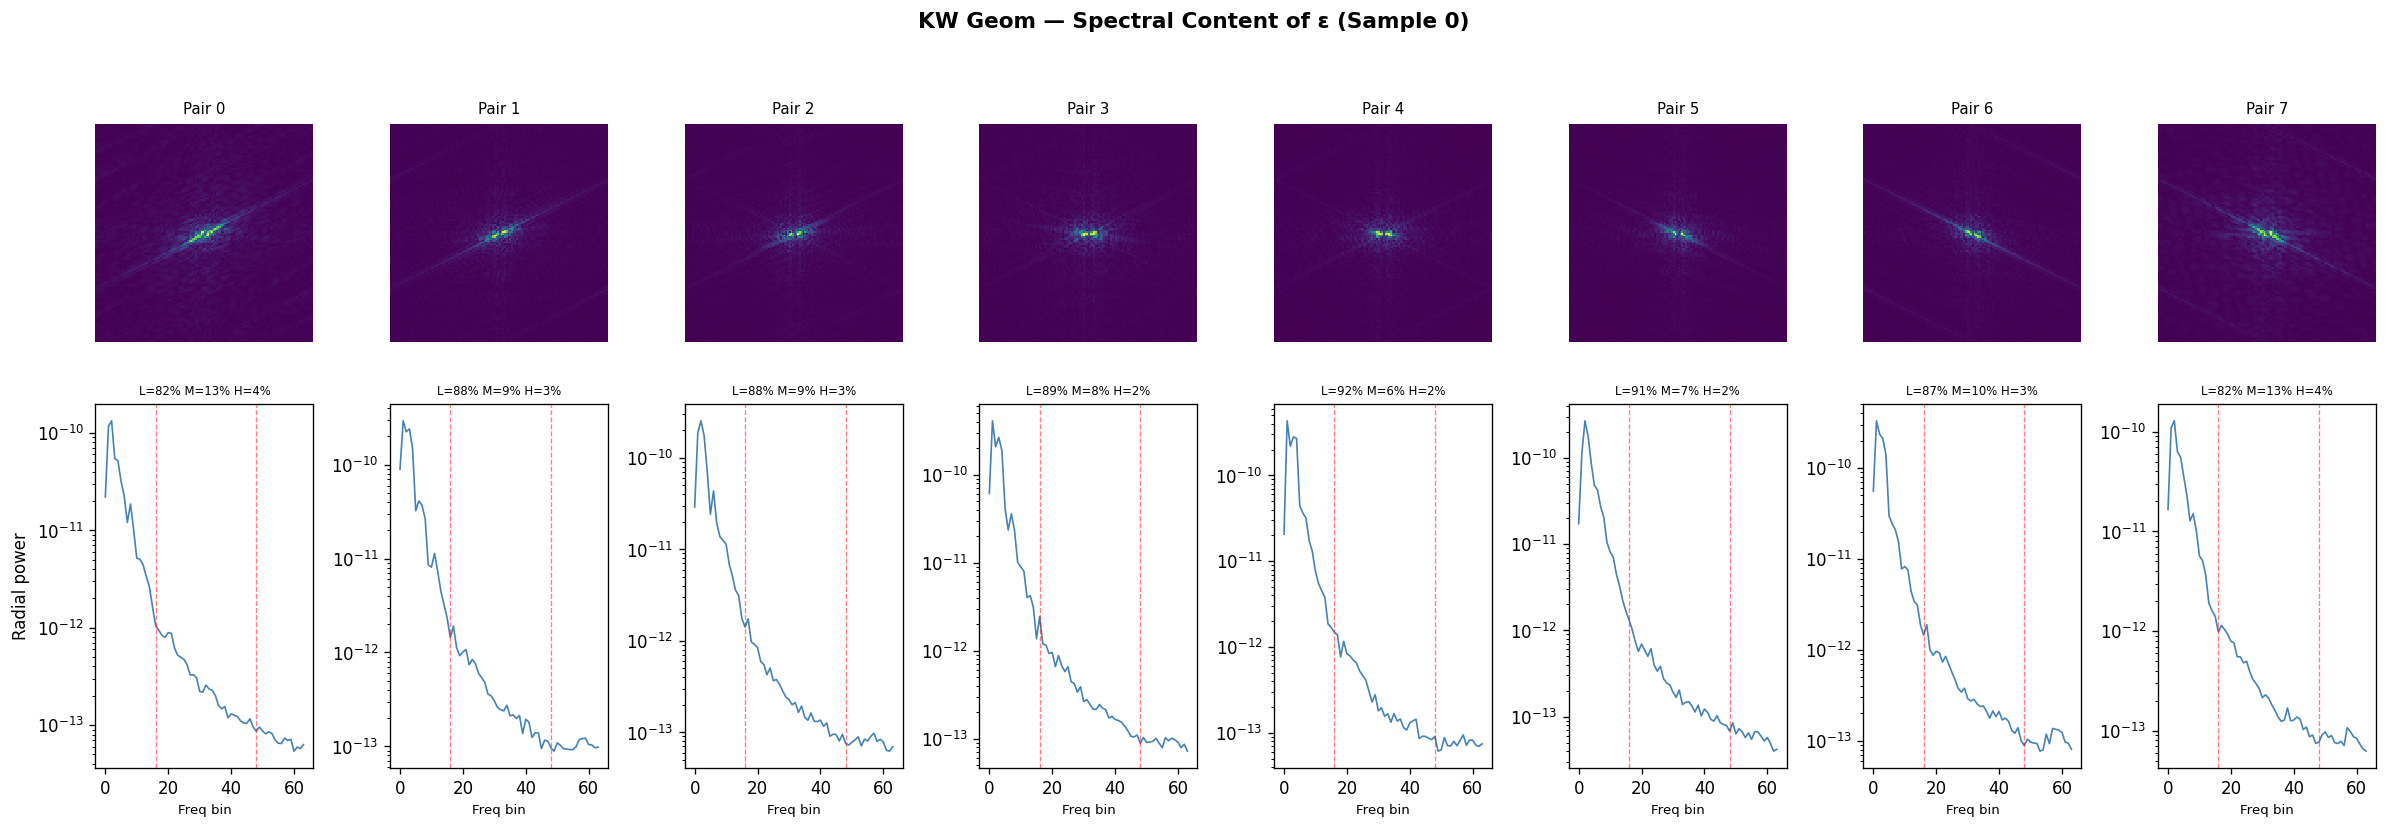

  Mean low-freq energy fraction: 87.4%


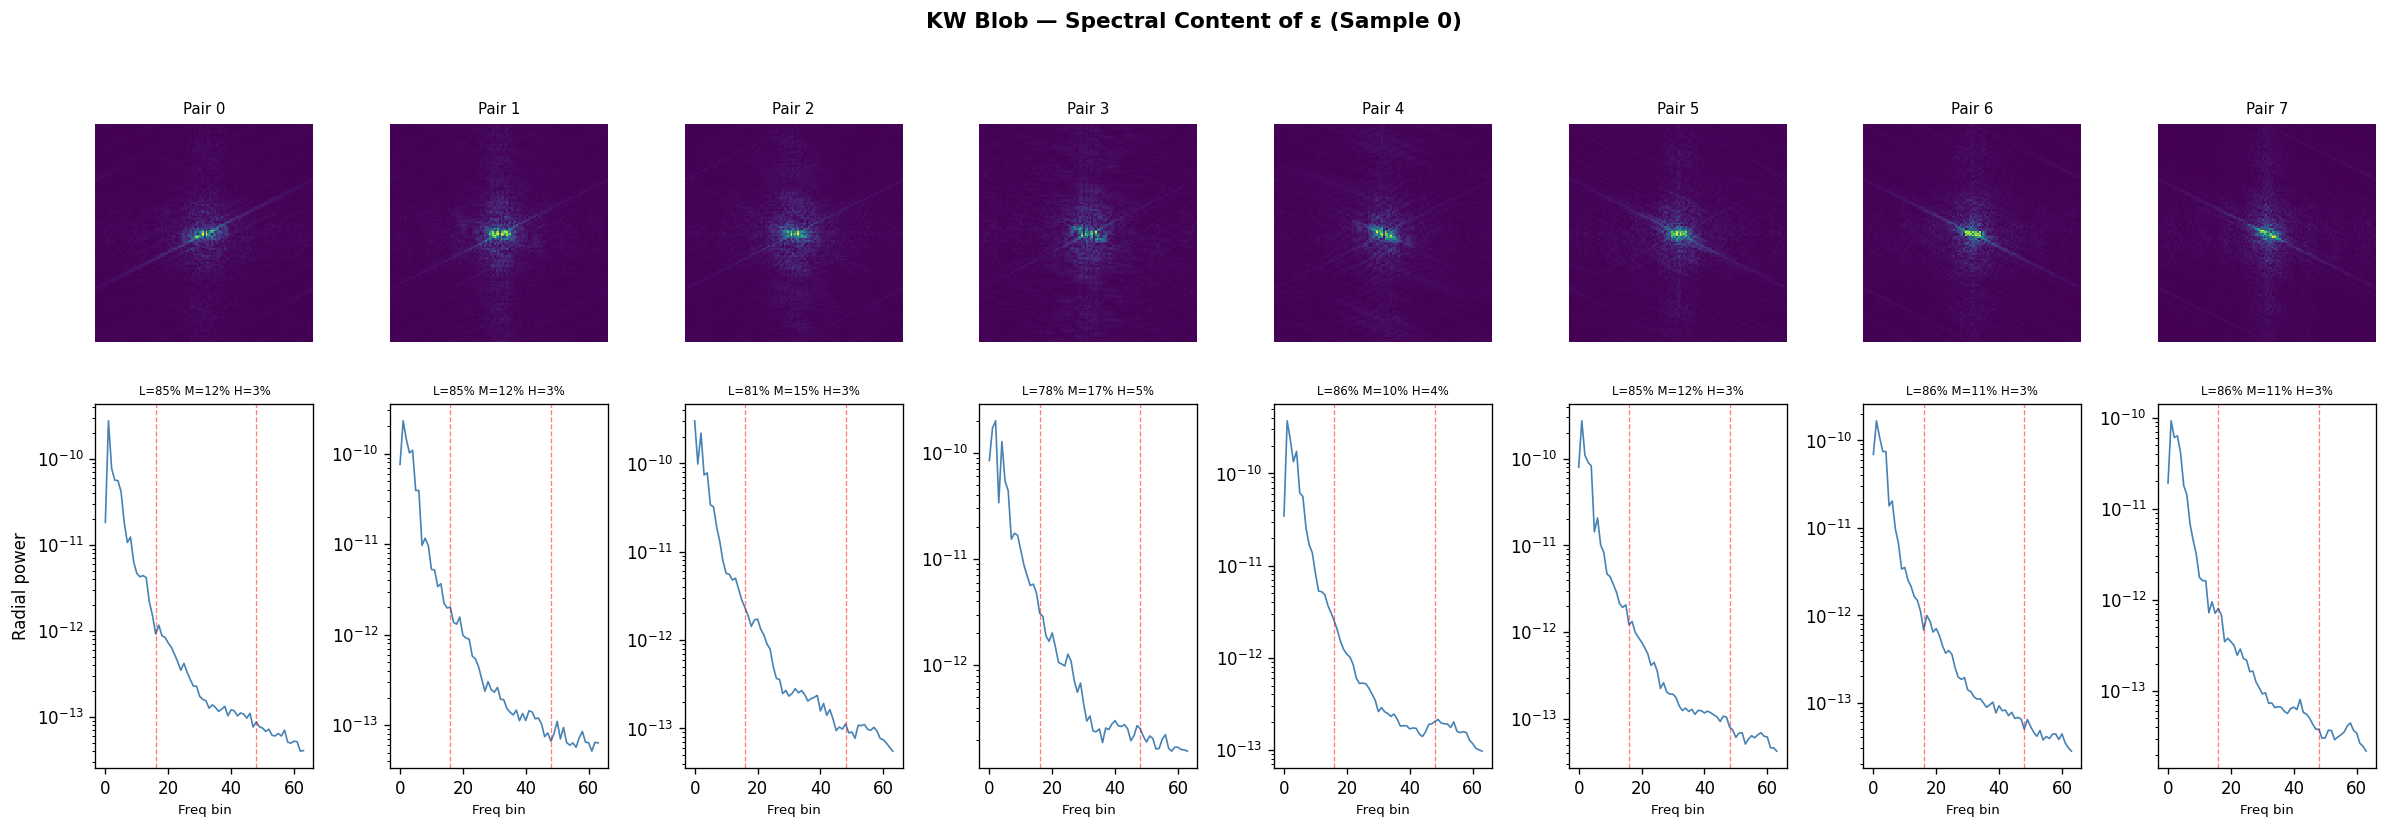

  Mean low-freq energy fraction: 84.1%


In [33]:
# Spectral analysis of ε: per firing pair, compute 2D FFT and analyze energy by frequency band
def spectral_analysis_mismatch(mismatch_list, label, sample_idx=0):
    """2D FFT analysis of mismatch ε per firing pair."""
    eps = mismatch_list[sample_idx]['epsilon']
    mask = mismatch_list[sample_idx]['mask']
    pair_size = len(eps) // n_pairs
    
    fig, axes = plt.subplots(2, n_pairs, figsize=(20, 7))
    fig.suptitle(f"{label} — Spectral Content of ε (Sample {sample_idx})", 
                 fontsize=13, fontweight='bold')
    
    low_energy_fracs = []
    
    for p in range(n_pairs):
        sl = slice(p * pair_size, (p + 1) * pair_size)
        eps_pair = eps[sl].reshape(128, 128, order='F')
        mask_pair = mask[sl].reshape(128, 128, order='F')
        
        # Zero out invalid rays for FFT
        eps_masked = eps_pair * mask_pair
        
        # 2D FFT
        fft = np.fft.fft2(eps_masked)
        fft_shifted = np.fft.fftshift(fft)
        magnitude = np.abs(fft_shifted)
        log_mag = np.log1p(magnitude)
        
        # Top: FFT magnitude
        im = axes[0, p].imshow(log_mag, cmap='viridis', interpolation='nearest')
        axes[0, p].set_title(f"Pair {p}", fontsize=9)
        axes[0, p].axis('off')
        
        # Compute energy in low vs high frequency bands
        cy, cx = 64, 64  # center
        Y, X = np.ogrid[:128, :128]
        r = np.sqrt((X - cx)**2 + (Y - cy)**2)
        
        total_energy = np.sum(magnitude**2)
        low_mask = r <= 16  # low freq: inner 25% of spatial frequencies
        mid_mask = (r > 16) & (r <= 48)
        high_mask = r > 48
        
        low_energy = np.sum(magnitude[low_mask]**2) / (total_energy + 1e-30)
        mid_energy = np.sum(magnitude[mid_mask]**2) / (total_energy + 1e-30)
        high_energy = np.sum(magnitude[high_mask]**2) / (total_energy + 1e-30)
        low_energy_fracs.append(low_energy)
        
        # Bottom: radial power spectrum
        max_r = 64
        radial_bins = np.arange(0, max_r + 1)
        radial_power = np.zeros(max_r)
        for i in range(max_r):
            ring = (r >= radial_bins[i]) & (r < radial_bins[i+1])
            if ring.sum() > 0:
                radial_power[i] = np.mean(magnitude[ring]**2)
        
        axes[1, p].plot(radial_power, color='steelblue', linewidth=1)
        axes[1, p].set_yscale('log')
        axes[1, p].set_xlabel('Freq bin', fontsize=8)
        axes[1, p].set_title(f"L={low_energy:.0%} M={mid_energy:.0%} H={high_energy:.0%}", fontsize=7)
        axes[1, p].axvline(16, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
        axes[1, p].axvline(48, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    
    axes[0, 0].set_ylabel("FFT magnitude", fontsize=10)
    axes[1, 0].set_ylabel("Radial power", fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print(f"  Mean low-freq energy fraction: {np.mean(low_energy_fracs):.1%}")

spectral_analysis_mismatch(kw_geom_mismatch, "KW Geom")
spectral_analysis_mismatch(kw_blob_mismatch, "KW Blob")

### 7b. Signal vs Mismatch Spectral Overlap

The claim: mismatch ε occupies the **same frequency band** as the signal `L @ s_true`.
Let's verify by overlaying their radial power spectra directly.

In [ ]:
# Compare spectral content: signal (L @ s_true) vs mismatch (epsilon)
# Overlay radial power spectra to show they occupy the same frequency band

def spectral_overlap_analysis(mismatch_list, L, path, label, sample_idx=0):
    """Overlay radial power spectra of signal and mismatch per firing pair."""
    eps = mismatch_list[sample_idx]['epsilon']
    mask = mismatch_list[sample_idx]['mask']
    
    # Compute signal: L @ s_true for this sample
    with h5py.File(path, 'r') as f:
        s_gt = np.array(f['imgs_gt'][sample_idx]).flatten(order='F')
    signal = L @ s_gt  # d_ray = L @ s_true
    
    pair_size = len(eps) // n_pairs
    
    fig, axes = plt.subplots(2, n_pairs, figsize=(20, 8))
    fig.suptitle(f"{label} — Signal vs Mismatch Spectral Overlap (Sample {sample_idx})",
                 fontsize=13, fontweight='bold')
    
    overlap_scores = []
    
    for p in range(n_pairs):
        sl = slice(p * pair_size, (p + 1) * pair_size)
        
        # Reshape to 2D
        eps_pair = eps[sl].reshape(128, 128, order='F')
        sig_pair = signal[sl].reshape(128, 128, order='F')
        mask_pair = mask[sl].reshape(128, 128, order='F')
        
        # Zero out invalid rays
        eps_masked = eps_pair * mask_pair
        sig_masked = sig_pair * mask_pair
        
        # 2D FFT
        fft_eps = np.fft.fftshift(np.fft.fft2(eps_masked))
        fft_sig = np.fft.fftshift(np.fft.fft2(sig_masked))
        mag_eps = np.abs(fft_eps)
        mag_sig = np.abs(fft_sig)
        
        # Radial distance from center
        cy, cx = 64, 64
        Y, X = np.ogrid[:128, :128]
        r = np.sqrt((X - cx)**2 + (Y - cy)**2)
        
        # Radial power spectra
        max_r = 64
        radial_sig = np.zeros(max_r)
        radial_eps = np.zeros(max_r)
        for i in range(max_r):
            ring = (r >= i) & (r < i + 1)
            if ring.sum() > 0:
                radial_sig[i] = np.mean(mag_sig[ring]**2)
                radial_eps[i] = np.mean(mag_eps[ring]**2)
        
        # Normalize each to [0, 1] for shape comparison
        norm_sig = radial_sig / (radial_sig.max() + 1e-30)
        norm_eps = radial_eps / (radial_eps.max() + 1e-30)
        
        # Top row: normalized overlay (shape comparison)
        axes[0, p].plot(norm_sig, color='steelblue', linewidth=1.5, label='Signal (L@s)')
        axes[0, p].plot(norm_eps, color='crimson', linewidth=1.5, label='Mismatch (ε)')
        axes[0, p].set_yscale('log')
        axes[0, p].set_ylim(1e-6, 2)
        axes[0, p].set_title(f'Pair {p}', fontsize=9)
        axes[0, p].axvline(16, color='gray', ls='--', alpha=0.4, lw=0.8)
        if p == 0:
            axes[0, p].set_ylabel('Normalized power', fontsize=10)
            axes[0, p].legend(fontsize=7, loc='upper right')
        
        # Bottom row: absolute power (magnitude comparison)
        axes[1, p].plot(radial_sig, color='steelblue', linewidth=1.5, label='Signal')
        axes[1, p].plot(radial_eps, color='crimson', linewidth=1.5, label='Mismatch')
        axes[1, p].set_yscale('log')
        axes[1, p].set_xlabel('Freq bin', fontsize=8)
        axes[1, p].set_title(f'Pair {p}', fontsize=9)
        axes[1, p].axvline(16, color='gray', ls='--', alpha=0.4, lw=0.8)
        if p == 0:
            axes[1, p].set_ylabel('Absolute power', fontsize=10)
            axes[1, p].legend(fontsize=7, loc='upper right')
        
        # Compute overlap: correlation of normalized spectra
        corr = np.corrcoef(norm_sig, norm_eps)[0, 1]
        overlap_scores.append(corr)
    
    plt.tight_layout()
    plt.show()
    
    print(f"  Spectral shape correlation (signal vs mismatch): {np.mean(overlap_scores):.3f} ± {np.std(overlap_scores):.3f}")
    print(f"  Per pair: {[f'{c:.3f}' for c in overlap_scores]}")
    print(f"  → {'OVERLAPPING' if np.mean(overlap_scores) > 0.7 else 'PARTIALLY OVERLAPPING' if np.mean(overlap_scores) > 0.4 else 'SEPARABLE'} spectra")

print("KW Geom:")
spectral_overlap_analysis(kw_geom_mismatch, L_kw, KWAVE_GEOM_PATH, "KW Geom")
print("\nKW Blob:")
spectral_overlap_analysis(kw_blob_mismatch, L_kw, KWAVE_BLOB_PATH, "KW Blob")


## 8. What the Mismatch Does to Reconstruction (Oracle Analysis)

If we could subtract ε from d_meas, would INR work? Let's test with a simple "corrected" measurement: d_corrected = d_meas - ε_template (using leave-one-out template). This establishes the ceiling if we could perfectly correct the mismatch.

In [34]:
# Oracle analysis: what happens if we reconstruct from corrected measurements?
# We use least-squares (pseudoinverse) as a quick proxy — no INR needed for this diagnostic

def oracle_ls_reconstruction(path, L, mismatch_list, label, n_samples=6):
    """Compare LS reconstruction from raw vs corrected measurements."""
    
    # Only use valid rays (shared mask)
    common_mask = mismatch_list[0]['mask'].copy()
    for m in mismatch_list[:n_samples]:
        common_mask *= m['mask']
    valid_idx = common_mask > 0.5
    n_valid = valid_idx.sum()
    
    L_valid = L[valid_idx, :]
    
    # Precompute pseudoinverse (expensive but only once)
    print(f"Computing pseudoinverse of L_valid ({n_valid} x {L.shape[1]})...")
    L_pinv = np.linalg.pinv(L_valid)
    print(f"  Done. L_pinv shape: {L_pinv.shape}")
    
    results = {'raw': {'mae': [], 'ssim': []}, 'corrected': {'mae': [], 'ssim': []}}
    
    with h5py.File(path, 'r') as f:
        for i in range(min(n_samples, len(mismatch_list))):
            gt = f['imgs_gt'][i].flatten()
            gt_sos = slowness_to_sos(gt.reshape(64, 64, order='F'))
            
            d = f['measmnts'][i].flatten()
            d = np.nan_to_num(d, nan=0.0)
            d_valid = d[valid_idx]
            
            # Raw reconstruction
            s_raw = L_pinv @ d_valid
            raw_sos = slowness_to_sos(s_raw.reshape(64, 64, order='F'))
            
            # Corrected: subtract LOO template
            # LOO template = mean of all other samples' epsilon
            others_eps = [mismatch_list[j]['epsilon'][valid_idx] for j in range(len(mismatch_list)) if j != i]
            loo_template = np.mean(others_eps, axis=0)
            d_corrected = d_valid - loo_template
            
            s_corr = L_pinv @ d_corrected
            corr_sos = slowness_to_sos(s_corr.reshape(64, 64, order='F'))
            
            # Metrics
            for name, recon in [('raw', raw_sos), ('corrected', corr_sos)]:
                err = np.abs(gt_sos - recon)
                results[name]['mae'].append(err.mean())
                dr = max(gt_sos.max(), recon.max()) - min(gt_sos.min(), recon.min())
                results[name]['ssim'].append(ssim(gt_sos, recon, data_range=dr))
    
    print(f"\n{label} — Pseudoinverse Oracle ({n_samples} samples):")
    for name in ['raw', 'corrected']:
        r = results[name]
        print(f"  {name:12s}: MAE={np.mean(r['mae']):6.2f} ± {np.std(r['mae']):5.2f}  "
              f"SSIM={np.mean(r['ssim']):6.4f} ± {np.std(r['ssim']):6.4f}")
    
    improvement = (np.mean(results['raw']['mae']) - np.mean(results['corrected']['mae']))
    pct = improvement / np.mean(results['raw']['mae']) * 100
    print(f"  MAE improvement from correction: {improvement:.2f} m/s ({pct:.1f}%)")
    
    return results

kw_geom_oracle = oracle_ls_reconstruction(KWAVE_GEOM_PATH, L, kw_geom_mismatch, "KW Geom")

Computing pseudoinverse of L_valid (67712 x 4096)...
  Done. L_pinv shape: (4096, 67712)

KW Geom — Pseudoinverse Oracle (6 samples):
  raw         : MAE=191.53 ± 13.41  SSIM=0.0102 ± 0.0020
  corrected   : MAE=175.16 ± 17.75  SSIM=0.0122 ± 0.0033
  MAE improvement from correction: 16.37 m/s (8.5%)


## 9. L-Matrix Conditioning and Null Space

The condition number of L determines how much measurement noise/mismatch gets amplified into reconstruction error. We also want to understand the null space — are there SoS patterns that L simply cannot see?

In [35]:
# L-matrix analysis: condition number, singular values, null space
# Use only valid rays (common mask across kwave_geom samples)

common_mask = np.ones(L.shape[0])
with h5py.File(KWAVE_GEOM_PATH, 'r') as f:
    for i in range(f['nanidx'].shape[0]):
        m = 1.0 - f['nanidx'][i].flatten()
        common_mask *= m

valid_idx = common_mask > 0.5
L_valid = L[valid_idx, :]
print(f"L_valid shape: {L_valid.shape} (from {L.shape[0]} total rays)")

# SVD (this may take a moment for 70k x 4096)
print("Computing SVD of L_valid...")
U, S, Vt = np.linalg.svd(L_valid, full_matrices=False)
print(f"Done. Singular values range: [{S.min():.4e}, {S.max():.4e}]")
print(f"Condition number: {S.max() / S.min():.4e}")

# How many effective degrees of freedom?
threshold = S.max() * 1e-6
n_effective = (S > threshold).sum()
print(f"Effective rank (σ > {threshold:.2e}): {n_effective} / {len(S)}")

# Energy captured by top-k singular values
cumulative_energy = np.cumsum(S**2) / np.sum(S**2)
for pct in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cumulative_energy, pct) + 1
    print(f"  {pct:.0%} energy captured by top {k} singular values")

L_valid shape: (61843, 4096) (from 131072 total rays)
Computing SVD of L_valid...
Done. Singular values range: [3.9171e-15, 1.0520e-01]
Condition number: 2.6855e+13
Effective rank (σ > 1.05e-07): 4050 / 4096
  90% energy captured by top 86 singular values
  95% energy captured by top 122 singular values
  99% energy captured by top 221 singular values


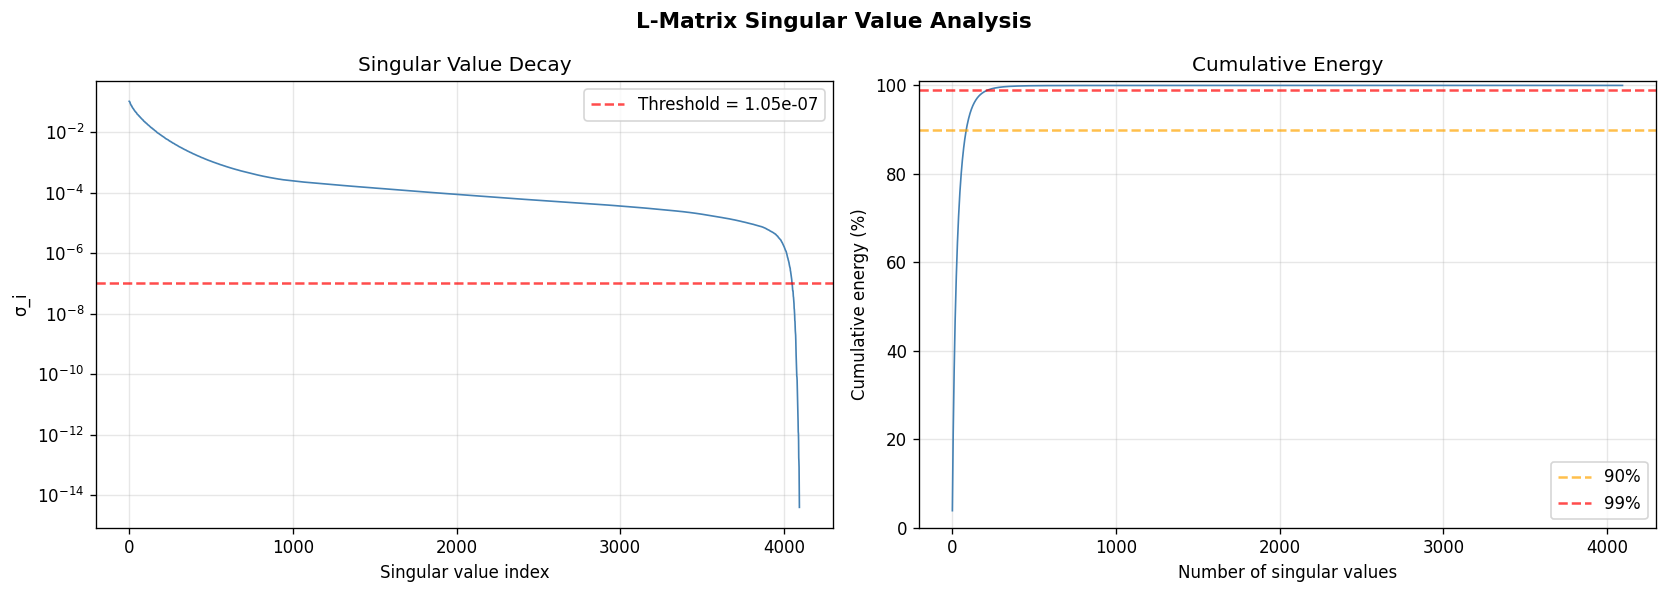

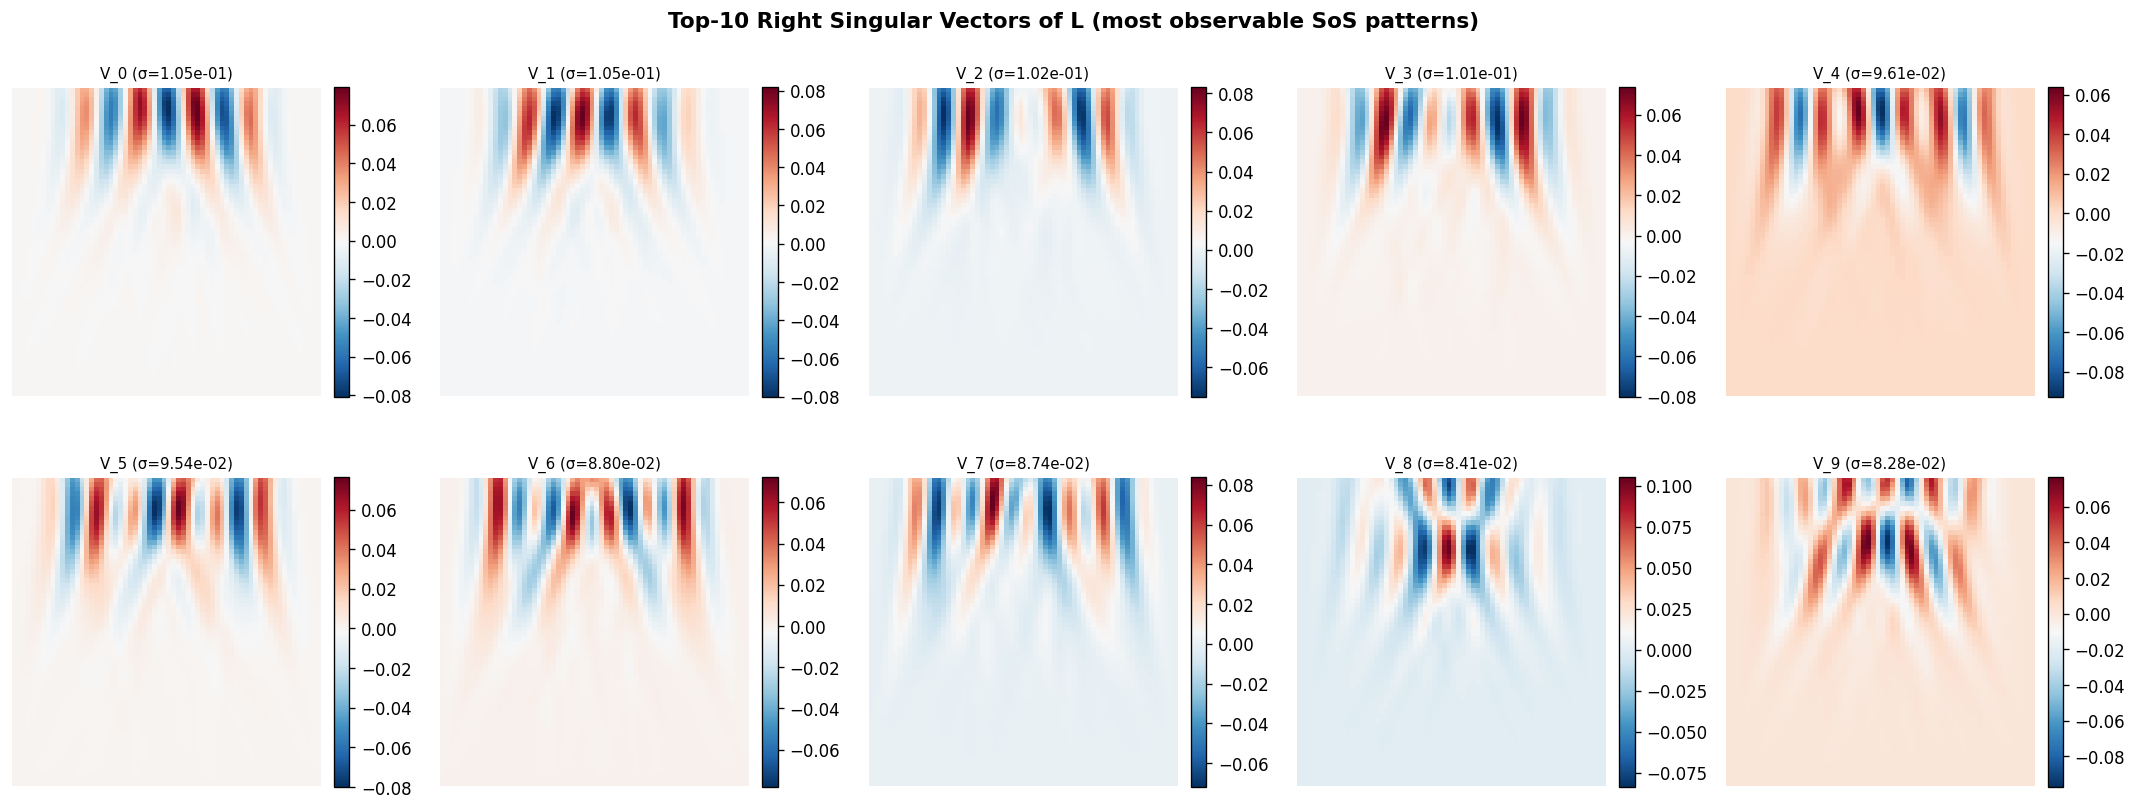

In [36]:
# Singular value decay plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("L-Matrix Singular Value Analysis", fontsize=13, fontweight='bold')

ax1.semilogy(S, color='steelblue', linewidth=1)
ax1.axhline(threshold, color='red', linestyle='--', alpha=0.7, label=f'Threshold = {threshold:.2e}')
ax1.set_xlabel("Singular value index")
ax1.set_ylabel("σ_i")
ax1.set_title("Singular Value Decay")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(cumulative_energy * 100, color='steelblue', linewidth=1)
ax2.axhline(90, color='orange', linestyle='--', alpha=0.7, label='90%')
ax2.axhline(99, color='red', linestyle='--', alpha=0.7, label='99%')
ax2.set_xlabel("Number of singular values")
ax2.set_ylabel("Cumulative energy (%)")
ax2.set_title("Cumulative Energy")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 101])

plt.tight_layout()
plt.show()

# Visualize top singular vectors (what spatial patterns L is most sensitive to)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Top-10 Right Singular Vectors of L (most observable SoS patterns)", 
             fontsize=13, fontweight='bold')
for i in range(10):
    ax = axes[i // 5, i % 5]
    v = Vt[i, :].reshape(64, 64, order='F')
    im = ax.imshow(v, cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f"V_{i} (σ={S[i]:.2e})", fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 10. Mismatch Projection onto Singular Vectors

Critical question: Does the mismatch ε project primarily onto the *well-conditioned* directions (large σ, recoverable) or the *ill-conditioned* directions (small σ, amplified)? If ε lives in the ill-conditioned subspace, even tiny mismatch causes huge reconstruction errors.

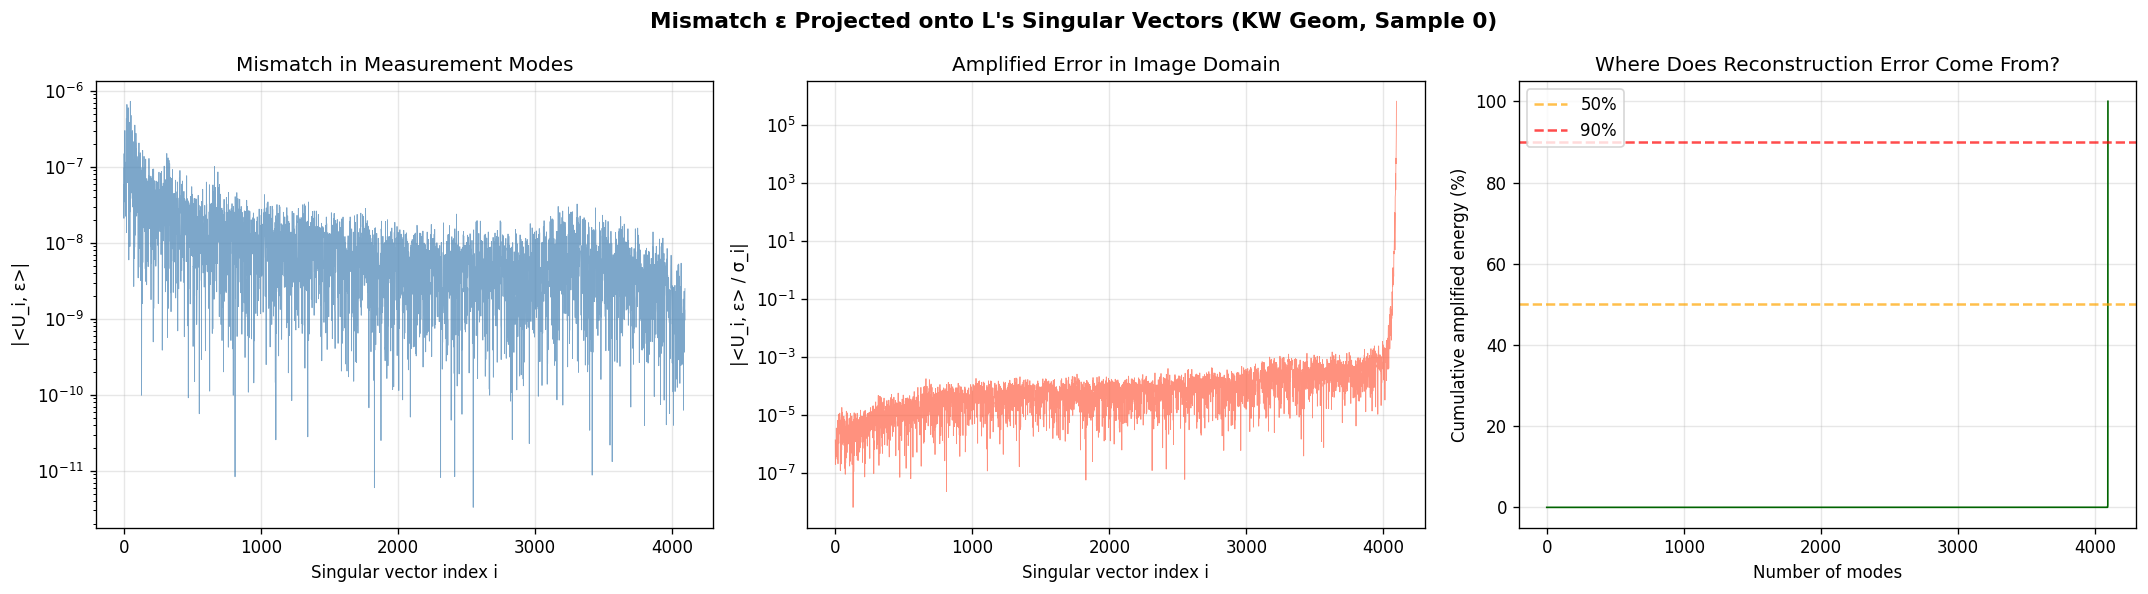

50% of amplified error from first 4096 modes (out of 4096)
90% of amplified error from first 4096 modes
Top mode amplification: |ε_0/σ_0| = 1.4099e-06
Last mode amplification: |ε_N/σ_N| = 6.3870e+05
Amplification ratio (last/first): 453004250377.9x


In [37]:
# Project mismatch onto left singular vectors of L
# ε_i = <U_i, ε> gives the component of ε in the i-th measurement mode
# The reconstruction error contribution from mode i is: ε_i / σ_i

eps_geom_0 = kw_geom_mismatch[0]['epsilon'][valid_idx]

# Project onto U
eps_proj = U.T @ eps_geom_0  # (4096,) — coefficient in each singular direction

# Amplified error in image domain: eps_proj / sigma
amplified = eps_proj / S

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mismatch ε Projected onto L's Singular Vectors (KW Geom, Sample 0)", 
             fontsize=13, fontweight='bold')

# (a) Raw projection coefficients
axes[0].semilogy(np.abs(eps_proj), color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].set_xlabel("Singular vector index i")
axes[0].set_ylabel("|<U_i, ε>|")
axes[0].set_title("Mismatch in Measurement Modes")
axes[0].grid(True, alpha=0.3)

# (b) Amplified error: |ε_i / σ_i|
axes[1].semilogy(np.abs(amplified), color='tomato', linewidth=0.5, alpha=0.7)
axes[1].set_xlabel("Singular vector index i")
axes[1].set_ylabel("|<U_i, ε> / σ_i|")
axes[1].set_title("Amplified Error in Image Domain")
axes[1].grid(True, alpha=0.3)

# (c) Cumulative amplified energy: where does the error come from?
cumul_amp = np.cumsum(amplified**2) / np.sum(amplified**2) * 100
axes[2].plot(cumul_amp, color='darkgreen', linewidth=1)
axes[2].axhline(50, color='orange', linestyle='--', alpha=0.7, label='50%')
axes[2].axhline(90, color='red', linestyle='--', alpha=0.7, label='90%')
axes[2].set_xlabel("Number of modes")
axes[2].set_ylabel("Cumulative amplified energy (%)")
axes[2].set_title("Where Does Reconstruction Error Come From?")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key stats
n_50 = np.searchsorted(cumul_amp, 50) + 1
n_90 = np.searchsorted(cumul_amp, 90) + 1
print(f"50% of amplified error from first {n_50} modes (out of {len(S)})")
print(f"90% of amplified error from first {n_90} modes")
print(f"Top mode amplification: |ε_0/σ_0| = {np.abs(amplified[0]):.4e}")
print(f"Last mode amplification: |ε_N/σ_N| = {np.abs(amplified[-1]):.4e}")
print(f"Amplification ratio (last/first): {np.abs(amplified[-1])/np.abs(amplified[0]):.1f}x")

## 11. Correlation Vector Analysis

K-wave datasets include pre-computed correlation vectors. These represent the cross-correlation quality between transmitted and received signals. Low correlation suggests unreliable measurements — potentially useful as weights or additional masking.

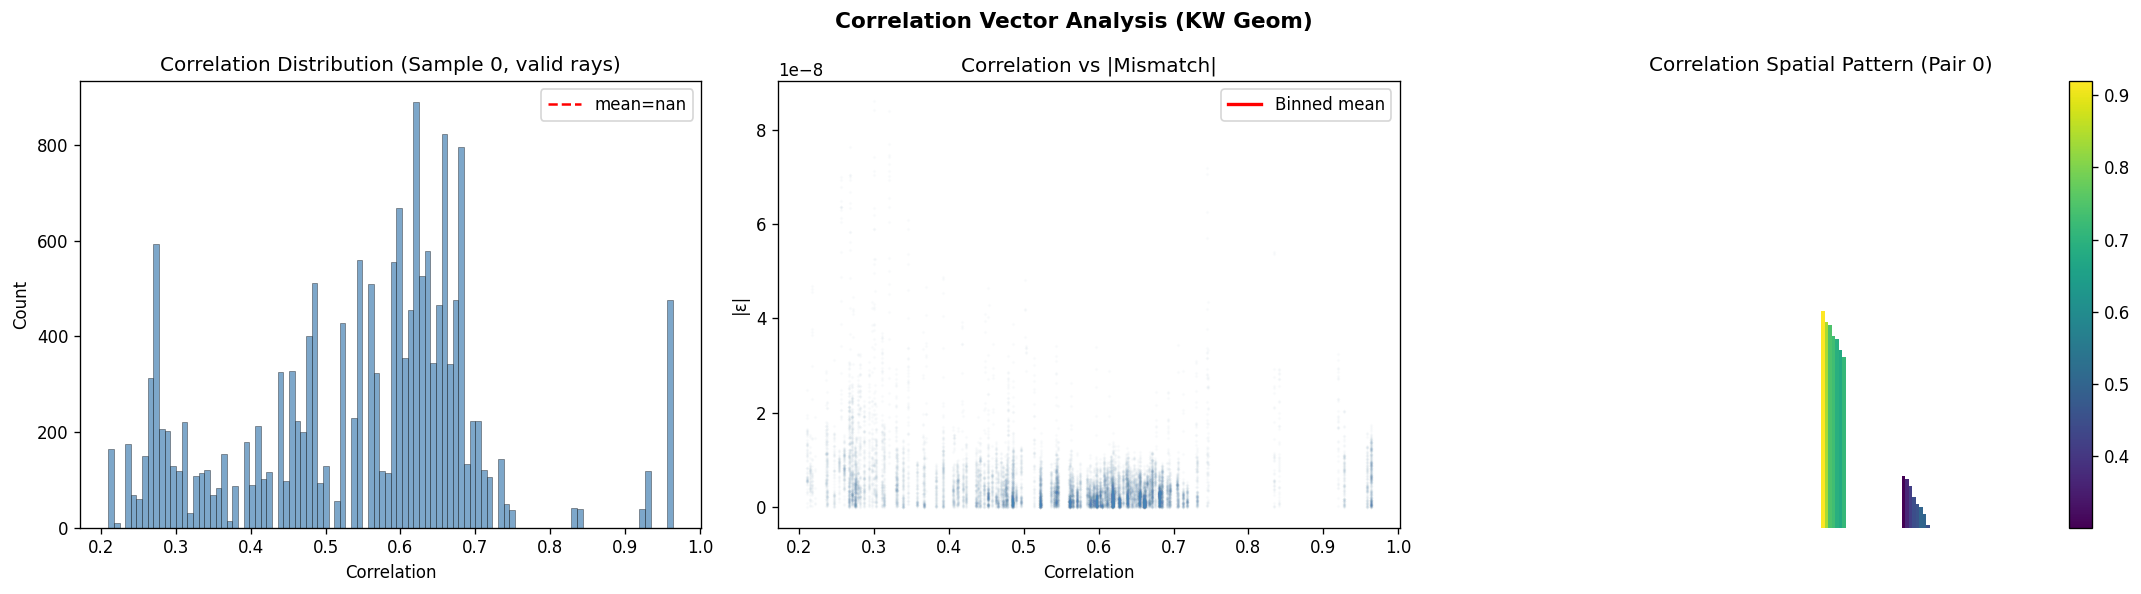

Pearson correlation between correlation_vector and |ε|: nan
→ NOT a useful predictor of mismatch


In [38]:
# Correlation vector analysis
if 'all_correlation_vector' in kw_geom_data:
    corr = kw_geom_data['all_correlation_vector']
    mask = kw_geom_mask
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Correlation Vector Analysis (KW Geom)", fontsize=13, fontweight='bold')
    
    # (a) Histogram of correlation values (valid rays only)
    c0 = corr[0].flatten()
    m0 = mask[0].flatten()
    valid_corr = c0[m0 > 0.5]
    axes[0].hist(valid_corr, bins=100, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.3)
    axes[0].set_xlabel("Correlation")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Correlation Distribution (Sample 0, valid rays)")
    axes[0].axvline(valid_corr.mean(), color='red', linestyle='--', label=f'mean={valid_corr.mean():.3f}')
    axes[0].legend()
    
    # (b) Correlation vs mismatch magnitude — is low correlation = high mismatch?
    eps0 = kw_geom_mismatch[0]['epsilon']
    valid = m0 > 0.5
    axes[1].scatter(c0[valid], np.abs(eps0[valid]), alpha=0.02, s=1, color='steelblue')
    axes[1].set_xlabel("Correlation")
    axes[1].set_ylabel("|ε|")
    axes[1].set_title("Correlation vs |Mismatch|")
    
    # Binned mean
    bins = np.linspace(valid_corr.min(), valid_corr.max(), 30)
    bin_idx = np.digitize(c0[valid], bins)
    bin_means = []
    bin_centers = []
    for b in range(1, len(bins)):
        in_bin = bin_idx == b
        if in_bin.sum() > 10:
            bin_means.append(np.mean(np.abs(eps0[valid][in_bin])))
            bin_centers.append((bins[b-1] + bins[b]) / 2)
    axes[1].plot(bin_centers, bin_means, 'r-', linewidth=2, label='Binned mean')
    axes[1].legend()
    
    # (c) Spatial pattern of correlation (one firing pair)
    c_pair = c0[:pair_size].reshape(128, 128, order='F')
    im = axes[2].imshow(c_pair, cmap='viridis', interpolation='nearest')
    axes[2].set_title("Correlation Spatial Pattern (Pair 0)")
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation between correlation and |ε|
    r_corr_eps = np.corrcoef(c0[valid], np.abs(eps0[valid]))[0, 1]
    print(f"Pearson correlation between correlation_vector and |ε|: {r_corr_eps:.4f}")
    print(f"→ {'Useful predictor' if abs(r_corr_eps) > 0.3 else 'NOT a useful predictor'} of mismatch")
else:
    print("No correlation vectors in kwave_geom data")

## 12. Summary & Key Questions for Next Steps

Run the cells above and fill in findings below:

### Findings Template (fill after running)

| Question | IC | KW Geom | KW Blob |
|----------|----|---------|---------| 
| Valid rays % | ? | ? | ? |
| ε energy % | ~0% | ? | ? |
| ε systematic? | N/A | ? | ? |
| L condition number | — | ? | — |
| Correlation predicts ε? | N/A | ? | ? |
| L1 baseline MAE | N/A | ? | ? |
| L2 baseline MAE | N/A | ? | ? |
| LS oracle (raw) MAE | N/A | ? | ? |
| LS oracle (corrected) MAE | N/A | ? | ? |

### Key Questions This Notebook Should Answer:
1. **How much information is lost?** (mask analysis — what fraction of the measurement vector is usable?)
2. **How structured is the mismatch?** (systematic vs random, per-pair patterns)
3. **What frequency band is the mismatch in?** (determines if spectral bias helps or hurts)
4. **Can template correction help?** (oracle analysis — ceiling with LOO correction)
5. **Where in singular value space does the error live?** (determines amplification severity)
6. **Is correlation a useful quality indicator?** (for weighted loss or additional masking)

### Literature-Informed Next Steps (based on findings):
- **Lozenski et al. (2025)**: Data-domain correction with CNN — but we have limited training data (32 samples)
- **Jagatap et al. (ICLR 2025)**: Untrained forward model residual — per-instance, no training data needed
- **Spectral bias control**: If ε is low-freq, we need to *prevent* INR from fitting it
- **Truncated SVD reconstruction**: If error amplification is the problem, truncating small singular values may help